In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import shap
import seaborn as sns
import re
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [39]:
file_path = r"C:\Users\mimarqu\Downloads\Nat2024us\Nat2024PublicUS.c20250512.r20250708.txt"

def p(start, end):
    return (start - 1, end)

spec = [
    ("DOB_YY", 9, 12), ("DOB_MM", 13, 14), ("DOB_TT", 19, 22), ("DOB_WK", 23, 23),
    ("BFACIL", 32, 32), ("F_BFACIL", 33, 33), ("BFACIL3", 50, 50),
    ("MAGE_IMPFLG", 73, 73), ("MAGE_REPFLG", 74, 74), ("MAGER", 75, 76),
    ("MAGER14", 77, 78), ("MAGER9", 79, 79), ("MBSTATE_REC", 84, 84),
    ("RESTATUS", 104, 104), ("MRACE31", 105, 106), ("MRACE6", 107, 107),
    ("MRACE15", 108, 109), ("MRACEIMP", 111, 111), ("MHISPX", 112, 112),
    ("MHISP_R", 115, 115), ("F_MHISP", 116, 116), ("MRACEHISP", 117, 117),
    ("MAR_P", 119, 119), ("DMAR", 120, 120), ("MAR_IMP", 121, 121),
    ("F_MAR_P", 123, 123), ("MEDUC", 124, 124), ("F_MEDUC", 126, 126),
    ("FAGERPT_FLG", 142, 142), ("FAGECOMB", 147, 148), ("FAGEREC11", 149, 150),
    ("FRACE31", 151, 152), ("FRACE6", 153, 153), ("FRACE15", 154, 155),
    ("FHISPX", 159, 159), ("FHISP_R", 160, 160), ("F_FHISP", 161, 161),
    ("FRACEHISP", 162, 162), ("FEDUC", 163, 163), ("F_FEDUC", 165, 165),
    ("PRIORLIVE", 171, 172), ("PRIORDEAD", 173, 174), ("PRIORTERM", 175, 176),
    ("LBO_REC", 179, 179), ("TBO_REC", 182, 182), ("ILLB_R", 198, 200),
    ("ILLB_R11", 201, 202), ("ILOP_R", 206, 208), ("ILOP_R11", 209, 210),
    ("ILP_R", 214, 216), ("ILP_R11", 217, 218), ("PRECARE", 224, 225),
    ("F_MPCB", 226, 226), ("PRECARE5", 227, 227), ("PREVIS", 238, 239),
    ("PREVIS_REC", 242, 243), ("F_TPCV", 244, 244), ("WIC", 251, 251),
    ("F_WIC", 252, 252), ("CIG_0", 253, 254), ("CIG_1", 255, 256),
    ("CIG_2", 257, 258), ("CIG_3", 259, 260), ("CIG_REC", 269, 269),
    ("M_Ht_In", 280, 281), ("BMI", 283, 286), ("BMI_R", 287, 287),
    ("PWgt_R", 292, 294), ("F_PWGT", 295, 295), ("DWgt_R", 299, 301),
    ("F_DWGT", 303, 303), ("WTGAIN", 304, 305), ("WTGAIN_REC", 306, 306),
    ("SEX", 475, 475), ("DLMP_MM", 477, 478), ("DLMP_YY", 481, 484),
    ("COMBGEST", 490, 491), ("GESTREC10", 492, 493), ("GESTREC3", 494, 494),
    ("OEGest_Comb", 499, 500), ("DBWT", 504, 507), ("BWTR12", 509, 510),
    ("BWTR4", 511, 511), ("CA_CLEFT", 550, 550), ("CA_CLPAL", 551, 551),
    ("ITRAN", 567, 567), ("ILIVE", 568, 568), ("BFED", 569, 569), ("F_BFED", 570, 570)
 ]

colspecs = [p(start, end) for _, start, end in spec]
names = [name for name, _, _ in spec]

nat2024us = pd.read_fwf(
    file_path,
    colspecs=colspecs,
    names=names,
    dtype="string",
    header=None
)

print(nat2024us.shape)
nat2024us.head()

(3638436, 89)


,DOB_YY,DOB_MM,DOB_TT,DOB_WK,BFACIL,F_BFACIL,BFACIL3,MAGE_IMPFLG,MAGE_REPFLG,MAGER,MAGER14,MAGER9,MBSTATE_REC,RESTATUS,MRACE31,MRACE6,MRACE15,MRACEIMP,MHISPX,MHISP_R,F_MHISP,MRACEHISP,MAR_P,DMAR,MAR_IMP,F_MAR_P,MEDUC,F_MEDUC,FAGERPT_FLG,FAGECOMB,FAGEREC11,FRACE31,FRACE6,FRACE15,FHISPX,FHISP_R,F_FHISP,FRACEHISP,FEDUC,F_FEDUC,PRIORLIVE,PRIORDEAD,PRIORTERM,LBO_REC,TBO_REC,ILLB_R,ILLB_R11,ILOP_R,ILOP_R11,ILP_R,ILP_R11,PRECARE,F_MPCB,PRECARE5,PREVIS,PREVIS_REC,F_TPCV,WIC,F_WIC,CIG_0,CIG_1,CIG_2,CIG_3,CIG_REC,M_Ht_In,BMI,BMI_R,PWgt_R,F_PWGT,DWgt_R,F_DWGT,WTGAIN,WTGAIN_REC,SEX,DLMP_MM,DLMP_YY,COMBGEST,GESTREC10,GESTREC3,OEGest_Comb,DBWT,BWTR12,BWTR4,CA_CLEFT,CA_CLPAL,ITRAN,ILIVE,BFED,F_BFED
0,2024,01,0501,2,1,1,1,<NA>,<NA>,30,10,5,1,1,02,2,02,<NA>,0,0,1,2,X,1,<NA>,1,3,1,<NA>,30,05,02,2,02,0,0,1,2,4,1,01,00,00,2,2,030,04,888,88,030,04,03,1,1,08,05,1,N,1,00,00,00,00,N,66,20.8,2,129,1,133,1,04,1,F,04,2023,38,06,2,38,2897,06,3,N,N,N,Y,Y,1
1,2024,01,0509,3,1,1,1,<NA>,<NA>,28,09,4,1,1,13,6,15,<NA>,0,0,1,6,X,1,<NA>,1,6,1,<NA>,28,04,10,6,15,1,1,1,7,3,1,00,00,00,1,1,888,88,888,88,888,88,03,1,1,13,08,1,N,1,00,00,00,00,N,67,20.4,2,130,1,170,1,40,4,F,04,2023,38,06,2,38,3175,07,3,N,N,N,Y,Y,1
2,2024,01,0525,3,1,1,1,<NA>,<NA>,41,12,7,1,1,01,1,01,<NA>,0,0,1,1,X,1,<NA>,1,6,1,<NA>,35,06,01,1,01,0,0,1,1,3,1,06,00,02,7,8,084,08,999,99,999,99,02,1,1,11,07,1,N,1,00,00,00,00,N,67,22.7,2,145,1,173,1,28,3,M,04,2023,37,06,2,37,2095,05,2,N,N,Y,Y,Y,1
3,2024,01,1910,2,2,1,2,<NA>,<NA>,29,09,4,1,2,01,1,01,<NA>,0,0,1,1,X,1,<NA>,1,4,1,<NA>,30,05,01,1,01,0,0,1,1,3,1,02,00,00,3,3,049,06,888,88,049,06,03,1,1,10,06,1,N,1,00,00,00,00,N,61,26.4,3,140,1,999,1,99,9,M,04,2023,38,06,2,39,3078,07,3,N,N,N,Y,Y,1
4,2024,01,2241,2,1,1,1,<NA>,<NA>,28,09,4,1,1,01,1,01,<NA>,0,0,1,1,X,1,<NA>,1,6,1,<NA>,29,04,01,1,01,0,0,1,1,4,1,01,00,02,2,4,017,02,011,01,011,01,02,1,1,13,08,1,N,1,00,00,00,00,N,64,21.5,2,125,1,156,1,31,4,F,04,2023,39,07,2,36,3070,07,3,N,N,N,Y,Y,1


In [40]:
# Cell 3: Data dictionary for analyzable features


description_map = {
    "DOB_YY": "Birth year",
    "DOB_MM": "Birth month",
    "DOB_TT": "Time of birth (HHMM)",
    "DOB_WK": "Day of week of birth",
    "BFACIL": "Birth place",
    "F_BFACIL": "Reporting flag for birth place",
    "BFACIL3": "Birth place recode",
    "MAGE_IMPFLG": "Mother's age imputed flag",
    "MAGE_REPFLG": "Mother reported age used flag",
    "MAGER": "Mother age (single years)",
    "MAGER14": "Mother age recode (14 groups)",
    "MAGER9": "Mother age recode (9 groups)",
    "MBSTATE_REC": "Mother nativity recode",
    "RESTATUS": "Residence status",
    "MRACE31": "Mother race recode (31)",
    "MRACE6": "Mother race recode (6)",
    "MRACE15": "Mother race recode (15)",
    "MRACEIMP": "Mother race imputed flag",
    "MHISPX": "Mother Hispanic origin",
    "MHISP_R": "Mother Hispanic origin recode",
    "F_MHISP": "Reporting flag for mother Hispanic origin",
    "MRACEHISP": "Mother race/Hispanic origin",
    "MAR_P": "Paternity acknowledged",
    "DMAR": "Marital status",
    "MAR_IMP": "Marital status imputed flag",
    "F_MAR_P": "Reporting flag for paternity acknowledged",
    "MEDUC": "Mother education",
    "F_MEDUC": "Reporting flag for mother education",
    "FAGERPT_FLG": "Father reported age used flag",
    "FAGECOMB": "Father combined age",
    "FAGEREC11": "Father age recode (11)",
    "FRACE31": "Father race recode (31)",
    "FRACE6": "Father race recode (6)",
    "FRACE15": "Father race recode (15)",
    "FHISPX": "Father Hispanic origin",
    "FHISP_R": "Father Hispanic origin recode",
    "F_FHISP": "Reporting flag for father Hispanic origin",
    "FRACEHISP": "Father race/Hispanic origin",
    "FEDUC": "Father education",
    "F_FEDUC": "Reporting flag for father education",
    "PRIORLIVE": "Prior live births now living",
    "PRIORDEAD": "Prior live births now dead",
    "PRIORTERM": "Prior other terminations",
    "LBO_REC": "Live birth order recode",
    "TBO_REC": "Total birth order recode",
    "ILLB_R": "Interval since last live birth (months recode)",
    "ILLB_R11": "Interval since last live birth recode (11)",
    "ILOP_R": "Interval since last other pregnancy",
    "ILOP_R11": "Interval since last other pregnancy recode (11)",
    "ILP_R": "Interval since last pregnancy",
    "ILP_R11": "Interval since last pregnancy recode (11)",
    "PRECARE": "Month prenatal care began",
    "F_MPCB": "Reporting flag for month prenatal care began",
    "PRECARE5": "Month prenatal care began recode",
    "PREVIS": "Number of prenatal visits",
    "PREVIS_REC": "Prenatal visits recode",
    "F_TPCV": "Reporting flag for prenatal care visits",
    "WIC": "Received WIC",
    "F_WIC": "Reporting flag for WIC",
    "CIG_0": "Cigarettes before pregnancy",
    "CIG_1": "Cigarettes in 1st trimester",
    "CIG_2": "Cigarettes in 2nd trimester",
    "CIG_3": "Cigarettes in 3rd trimester",
    "CIG_REC": "Any cigarette use recode",
    "M_Ht_In": "Mother height (inches)",
    "BMI": "Body Mass Index",
    "BMI_R": "BMI recode",
    "PWgt_R": "Pre-pregnancy weight (lbs)",
    "F_PWGT": "Reporting flag for pre-pregnancy weight",
    "DWgt_R": "Delivery weight (lbs)",
    "F_DWGT": "Reporting flag for delivery weight",
    "WTGAIN": "Weight gain (lbs)",
    "WTGAIN_REC": "Weight gain recode",
    "SEX": "Infant sex",
    "DLMP_MM": "Last normal menses month",
    "DLMP_YY": "Last normal menses year",
    "COMBGEST": "Combined gestation (weeks)",
    "GESTREC10": "Gestation recode (10)",
    "GESTREC3": "Gestation recode (3)",
    "OEGest_Comb": "Obstetric estimate gestation (weeks)",
    "DBWT": "Birth weight (grams)",
    "BWTR12": "Birth weight recode (12)",
    "BWTR4": "Birth weight recode (4)",
    "CA_CLEFT": "Cleft lip with/without cleft palate",
    "CA_CLPAL": "Cleft palate alone",
    "cleft_case": "Derived cleft case target (1=yes, 0=no)",
    "ITRAN": "Infant transferred",
    "ILIVE": "Infant living at report",
    "BFED": "Breastfed at discharge",
    "F_BFED": "Reporting flag for breastfed at discharge"
}

role_map = {
    "DBWT": "outcome", "BWTR12": "outcome", "BWTR4": "outcome",
    "COMBGEST": "outcome", "GESTREC10": "outcome", "GESTREC3": "outcome", "OEGest_Comb": "outcome",
    "ILIVE": "outcome", "BFED": "outcome",
    "cleft_case": "outcome", "SEX": "stratifier", "DOB_YY": "time_index", "DOB_MM": "time_index"
}

domain_map = {
    "birth_timing_place": ["DOB_YY","DOB_MM","DOB_TT","DOB_WK","BFACIL","BFACIL3","RESTATUS"],
    "maternal_demographics": ["MAGER","MAGER14","MAGER9","MBSTATE_REC","MRACE31","MRACE6","MRACE15","MHISPX","MHISP_R","MRACEHISP","DMAR","MAR_P","MEDUC"],
    "paternal_demographics": ["FAGECOMB","FAGEREC11","FRACE31","FRACE6","FRACE15","FHISPX","FHISP_R","FRACEHISP","FEDUC"],
    "pregnancy_history": ["PRIORLIVE","PRIORDEAD","PRIORTERM","LBO_REC","TBO_REC","ILLB_R","ILLB_R11","ILOP_R","ILOP_R11","ILP_R","ILP_R11"],
    "prenatal_behavior": ["PRECARE","PRECARE5","PREVIS","PREVIS_REC","WIC","CIG_0","CIG_1","CIG_2","CIG_3","CIG_REC"],
    "maternal_body": ["M_Ht_In","BMI","BMI_R","PWgt_R","DWgt_R","WTGAIN","WTGAIN_REC"],
    "infant_outcomes": ["COMBGEST","GESTREC10","GESTREC3","OEGest_Comb","DBWT","BWTR12","BWTR4","CA_CLEFT","CA_CLPAL","cleft_case","ILIVE","BFED","ITRAN","SEX"],
    "quality_flags": [c for c in nat2024us.columns if c.startswith("F_") or "IMP" in c]
}

feature_to_domain = {}
for domain, cols in domain_map.items():
    for col in cols:
        feature_to_domain[col] = domain

def friendly_name(col):
    if col in description_map:
        return description_map[col]
    text = col.replace("_", " ")
    text = re.sub(r"([a-z])([A-Z])", r"\1 \2", text)
    text = re.sub(r"([A-Za-z])(\d)", r"\1 \2", text)
    text = re.sub(r"(\d)([A-Za-z])", r"\1 \2", text)
    text = " ".join(text.split())
    return text.title()

def infer_kind(series):
    vals = series.dropna()
    if vals.empty:
        return "unknown"
    unique = vals.drop_duplicates()
    n_unique = len(unique)
    if n_unique <= 3 and set(unique.astype(str)).issubset({"Y", "N", "U", "X", "0", "1", "9", "<NA>"}):
        return "binary_or_flag"
    as_num = pd.to_numeric(vals, errors="coerce")
    numeric_ratio = as_num.notna().mean()
    if numeric_ratio > 0.95:
        return "numeric_or_ordered_code" if n_unique > 20 else "ordered_code"
    return "categorical_code"

sample_n = min(200000, len(nat2024us))
sample_df = nat2024us.sample(sample_n, random_state=42) if len(nat2024us) > sample_n else nat2024us

rows = []
for col in nat2024us.columns:
    s = nat2024us[col]
    sample_s = sample_df[col]
    rows.append({
        "feature": col,
        "description": friendly_name(col),
        "domain": feature_to_domain.get(col, "other"),
        "kind": infer_kind(s),
        "suggested_role": role_map.get(col, "predictor"),
        "missing_pct": round(s.isna().mean() * 100, 2),
        "n_unique_sample": int(sample_s.nunique(dropna=True)),
        "example_values": ", ".join(sample_s.dropna().astype(str).drop_duplicates().head(5).tolist())
    })

data_dictionary = pd.DataFrame(rows).sort_values(["domain", "feature"]).reset_index(drop=True)
data_dictionary

,feature,description,domain,kind,suggested_role,missing_pct,n_unique_sample,example_values
0,BFACIL,Birth place,birth_timing_place,ordered_code,predictor,0.00,8,"1, 3, 4, 2, 5"
1,BFACIL3,Birth place recode,birth_timing_place,ordered_code,predictor,0.00,3,"1, 2, 3"
2,DOB_MM,Birth month,birth_timing_place,ordered_code,time_index,0.00,12,"01, 12, 09, 08, 10"
3,DOB_TT,Time of birth (HHMM),birth_timing_place,numeric_or_ordered_code,predictor,0.00,1441,"1840, 1224, 0046, 1243, 0750"
4,DOB_WK,Day of week of birth,birth_timing_place,ordered_code,predictor,0.00,7,"3, 2, 5, 4, 1"
...,...,...,...,...,...,...,...,...
84,F_TPCV,Reporting flag for prenatal care visits,quality_flags,binary_or_flag,predictor,0.00,2,"1, 0"
85,F_WIC,Reporting flag for WIC,quality_flags,binary_or_flag,predictor,0.00,2,"1, 0"
86,MAGE_IMPFLG,Mother's age imputed flag,quality_flags,binary_or_flag,predictor,99.98,1,1
87,MAR_IMP,Marital status imputed flag,quality_flags,binary_or_flag,predictor,99.90,1,1


In [41]:
# Cell 4: Show full data dictionary (no truncation)
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.width", None
    ):
    display(data_dictionary)

,feature,description,domain,kind,suggested_role,missing_pct,n_unique_sample,example_values
0,BFACIL,Birth place,birth_timing_place,ordered_code,predictor,0.00,8,"1, 3, 4, 2, 5"
1,BFACIL3,Birth place recode,birth_timing_place,ordered_code,predictor,0.00,3,"1, 2, 3"
2,DOB_MM,Birth month,birth_timing_place,ordered_code,time_index,0.00,12,"01, 12, 09, 08, 10"
3,DOB_TT,Time of birth (HHMM),birth_timing_place,numeric_or_ordered_code,predictor,0.00,1441,"1840, 1224, 0046, 1243, 0750"
4,DOB_WK,Day of week of birth,birth_timing_place,ordered_code,predictor,0.00,7,"3, 2, 5, 4, 1"
5,DOB_YY,Birth year,birth_timing_place,ordered_code,time_index,0.00,1,2024
6,RESTATUS,Residence status,birth_timing_place,ordered_code,predictor,0.00,4,"1, 2, 3, 4"
7,BFED,Breastfed at discharge,infant_outcomes,binary_or_flag,outcome,0.00,3,"Y, N, U"
8,BWTR12,Birth weight recode (12),infant_outcomes,ordered_code,outcome,0.00,12,"06, 07, 08, 10, 05"
9,BWTR4,Birth weight recode (4),infant_outcomes,ordered_code,outcome,0.00,4,"3, 2, 1, 4"


## Appendix: Baseline Regression EDA (Optional)
This appendix preserves an earlier DBWT-focused exploration for reference.
It is not part of the final cleft-case rubric sections below.

In [42]:
# Part 1 setup
vivid_palette = ["#0078D4", "#E81123", "#FF8C00", "#00B7C3", "#7B61FF", "#00CC6A", "#C239B3", "#F7630C"]

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette=vivid_palette,
    rc={
        "font.family": "Segoe UI",
        "font.weight": "semibold",
        "axes.labelsize": 11,
        "axes.titlesize": 14,
        "axes.labelweight": "semibold",
        "axes.titleweight": "semibold",
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "legend.title_fontsize": 11,
    },
)

plt.rcParams["font.family"] = "Segoe UI"
plt.rcParams["font.weight"] = "semibold"
plt.rcParams["axes.labelweight"] = "semibold"
plt.rcParams["axes.titleweight"] = "semibold"

pd.set_option("display.max_columns", None)

target = "DBWT"

eda_cols = [
    target, "COMBGEST", "OEGest_Comb", "MAGER", "FAGECOMB", "PREVIS", "WTGAIN", "M_Ht_In", "BMI",
    "PRECARE", "PRECARE5", "SEX", "WIC", "CIG_REC", "MRACEHISP", "MEDUC", "BFACIL3", "ILIVE", "BFED"
]
eda_cols = [c for c in eda_cols if c in nat2024us.columns]

eda_df = nat2024us[eda_cols].copy()

numeric_candidates = ["DBWT", "COMBGEST", "OEGest_Comb", "MAGER", "FAGECOMB", "PREVIS", "WTGAIN", "M_Ht_In", "BMI", "PRECARE", "PRECARE5"]
numeric_candidates = [c for c in numeric_candidates if c in eda_df.columns]
for col in numeric_candidates:
    eda_df[col] = pd.to_numeric(eda_df[col], errors="coerce")

plot_n = min(200000, len(eda_df))
eda_sample = eda_df.sample(plot_n, random_state=42) if len(eda_df) > plot_n else eda_df

print(f"EDA sample rows: {len(eda_sample):,} (from total {len(eda_df):,})")
print(f"Target selected: {target}")

EDA sample rows: 200,000 (from total 3,638,436)
Target selected: DBWT


### A.1 Dataset Introduction (DBWT baseline)
- **What it contains:** U.S. natality microdata records (one row per birth event) with maternal, paternal, pregnancy, and infant outcome fields parsed from a fixed-width public-use file.
- **Source:** NCHS public natality file (`Nat2024PublicUS.c20250512.r20250708.txt`).
- **Prediction target:** `DBWT` (birth weight in grams, continuous).
- **Why this is impactful:** Understanding drivers of birth weight supports maternal/infant health risk stratification and public health planning.

In [43]:
# 1.1 Basic statistics
n_rows, n_features = nat2024us.shape

numeric_like = []
categorical_like = []
for col in nat2024us.columns:
    ratio_numeric = pd.to_numeric(nat2024us[col], errors="coerce").notna().mean()
    if ratio_numeric >= 0.98:
        numeric_like.append(col)
    else:
        categorical_like.append(col)

intro_stats = pd.DataFrame({
    "metric": [
        "Rows", "Features", "Numeric-like features", "Categorical-like features",
        "Target", "Target missing %", "Target unique values"
    ],
    "value": [
        f"{n_rows:,}",
        n_features,
        len(numeric_like),
        len(categorical_like),
        target,
        round(pd.to_numeric(nat2024us[target], errors='coerce').isna().mean() * 100, 2),
        int(pd.to_numeric(nat2024us[target], errors='coerce').nunique(dropna=True))
    ]
})

display(intro_stats)

,metric,value
0,Rows,"3,638,436"
1,Features,89
2,Numeric-like features,74
3,Categorical-like features,15
4,Target,DBWT
5,Target missing %,0.0
6,Target unique values,5285


### A.2 Target Distribution (DBWT baseline)
For this regression baseline, we visualize the distribution of birth weight (`DBWT`) and summarize skewness/outliers.

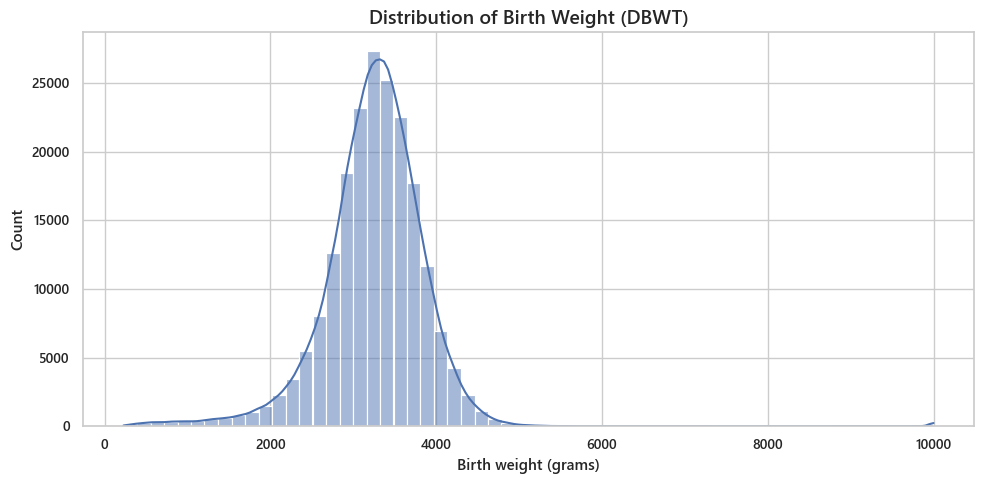

Interpretation: The target distribution is right-skewed (skew=0.51).
IQR outlier share is 3.39% using the 1.5*IQR rule.
Plan: Because this is regression (not class labels), we will handle skew/outliers with robust metrics and potential target transformation if needed.


In [44]:
# 1.2 Target distribution plot + interpretation
target_series = eda_sample[target].dropna()

plt.figure(figsize=(10, 5))
sns.histplot(target_series, bins=60, kde=True, color="#4C72B0")
plt.title("Distribution of Birth Weight (DBWT)")
plt.xlabel("Birth weight (grams)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

q1, q3 = target_series.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_share = ((target_series < lower) | (target_series > upper)).mean()
skewness = target_series.skew()

shape_comment = "approximately symmetric"
if skewness > 0.5:
    shape_comment = "right-skewed"
elif skewness < -0.5:
    shape_comment = "left-skewed"

print(f"Interpretation: The target distribution is {shape_comment} (skew={skewness:.2f}).")
print(f"IQR outlier share is {outlier_share*100:.2f}% using the 1.5*IQR rule.")
print("Plan: Because this is regression (not class labels), we will handle skew/outliers with robust metrics and potential target transformation if needed.")

### A.3 Feature Distributions and Relationships (DBWT baseline)
The next figure includes four baseline visualizations for `DBWT`.

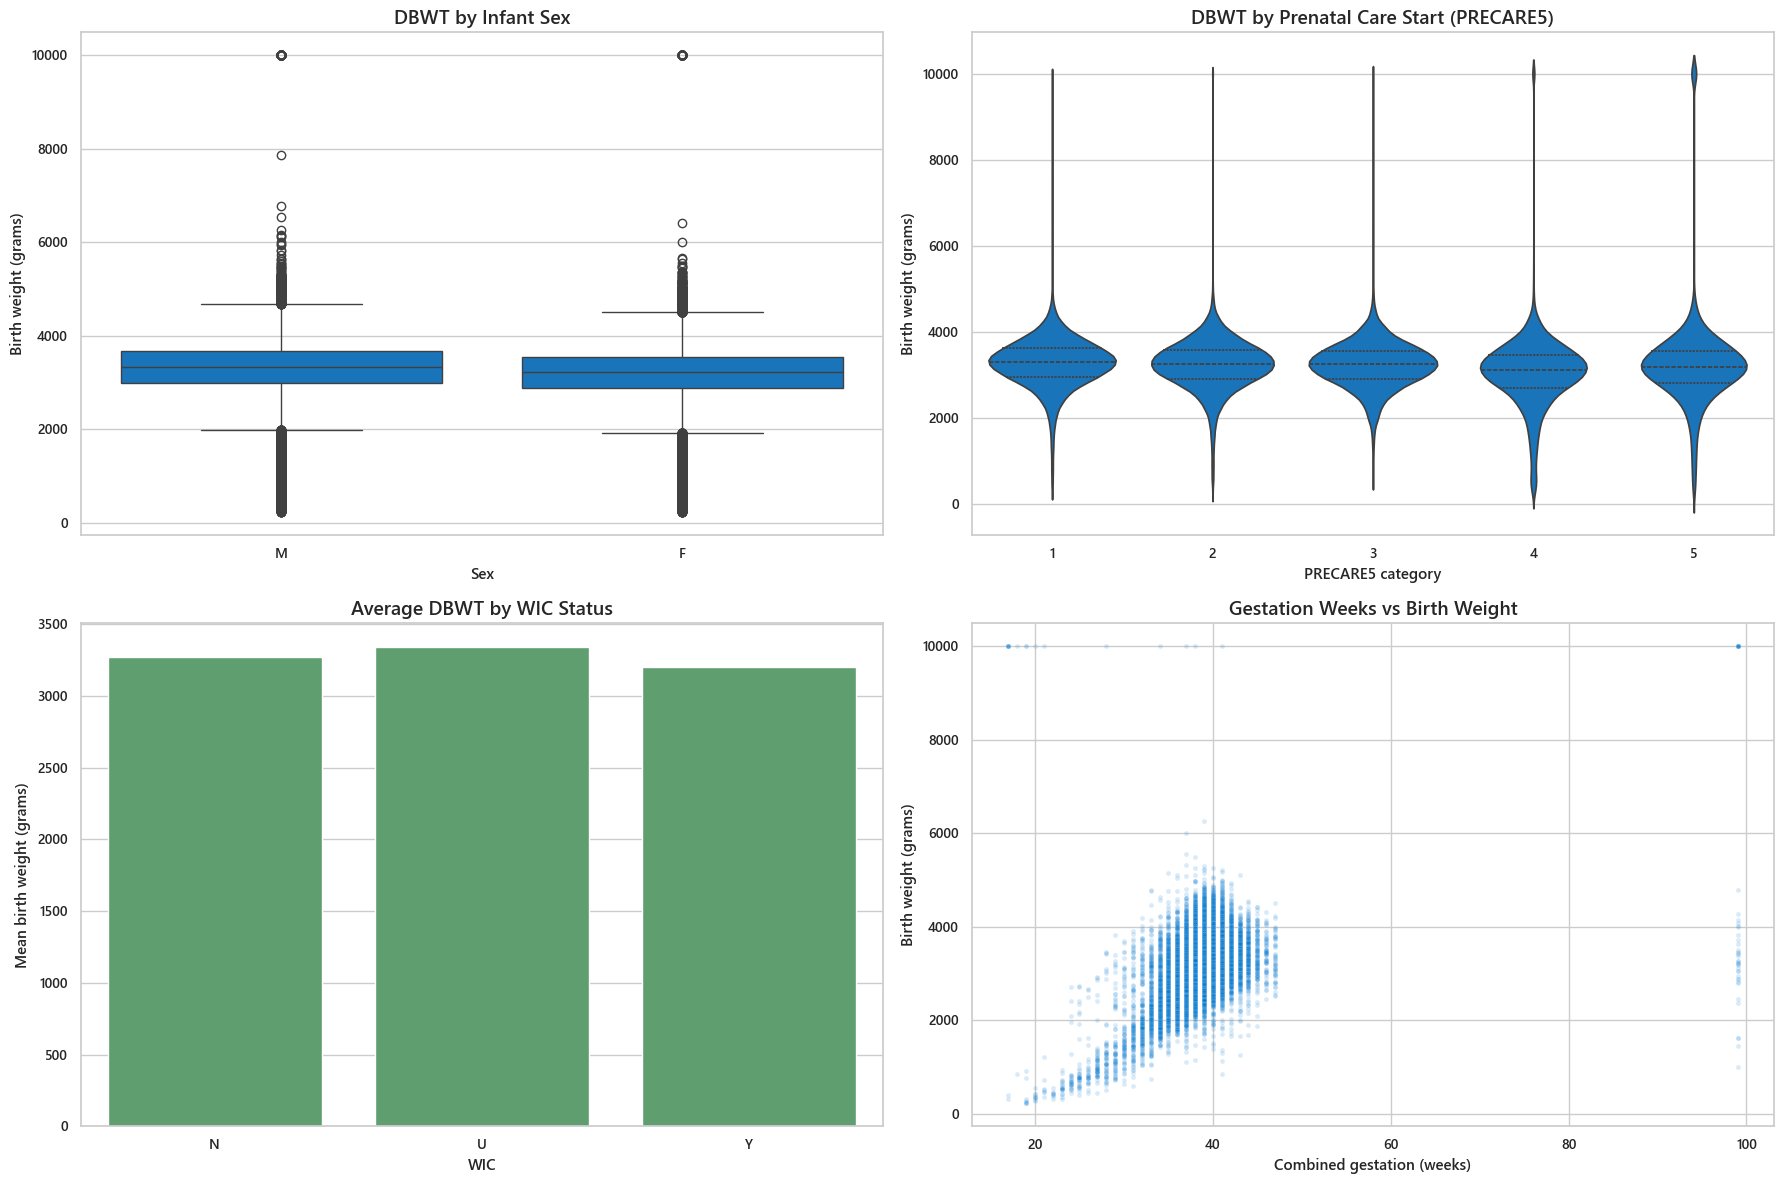

In [45]:
# 1.3 Four insightful visualizations
plot_df = eda_sample.copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# (1) Boxplot: DBWT by infant sex
sns.boxplot(data=plot_df.dropna(subset=["SEX", target]), x="SEX", y=target, ax=axes[0, 0])
axes[0, 0].set_title("DBWT by Infant Sex")
axes[0, 0].set_xlabel("Sex")
axes[0, 0].set_ylabel("Birth weight (grams)")

# (2) Violin: DBWT by prenatal care start recode
sns.violinplot(data=plot_df.dropna(subset=["PRECARE5", target]), x="PRECARE5", y=target, inner="quartile", ax=axes[0, 1])
axes[0, 1].set_title("DBWT by Prenatal Care Start (PRECARE5)")
axes[0, 1].set_xlabel("PRECARE5 category")
axes[0, 1].set_ylabel("Birth weight (grams)")

# (3) Mean target by WIC status
wic_means = plot_df.dropna(subset=["WIC", target]).groupby("WIC", as_index=False)[target].mean()
sns.barplot(data=wic_means, x="WIC", y=target, ax=axes[1, 0], color="#55A868")
axes[1, 0].set_title("Average DBWT by WIC Status")
axes[1, 0].set_xlabel("WIC")
axes[1, 0].set_ylabel("Mean birth weight (grams)")

# (4) Relationship: gestation vs birth weight
scatter_df = plot_df.dropna(subset=["COMBGEST", target]).sample(min(30000, plot_df.dropna(subset=["COMBGEST", target]).shape[0]), random_state=42)
sns.scatterplot(data=scatter_df, x="COMBGEST", y=target, alpha=0.15, s=12, ax=axes[1, 1])
axes[1, 1].set_title("Gestation Weeks vs Birth Weight")
axes[1, 1].set_xlabel("Combined gestation (weeks)")
axes[1, 1].set_ylabel("Birth weight (grams)")

plt.tight_layout()
plt.show()

In [46]:
# 1.3 Brief interpretations (2-3 sentences each)
sex_stats = plot_df.dropna(subset=["SEX", target]).groupby("SEX")[target].mean().sort_values()
precare_stats = plot_df.dropna(subset=["PRECARE5", target]).groupby("PRECARE5")[target].mean().sort_values()
wic_stats = plot_df.dropna(subset=["WIC", target]).groupby("WIC")[target].mean().sort_values()
corr_gest = plot_df[["COMBGEST", target]].dropna().corr().iloc[0, 1]

print("1) DBWT by Sex:")
print(f"Mean birth weight differs across infant sex categories; lowest={sex_stats.index[0]} ({sex_stats.iloc[0]:.1f}g), highest={sex_stats.index[-1]} ({sex_stats.iloc[-1]:.1f}g).")
print("The boxplot spread also shows substantial overlap, so sex alone is informative but not sufficient for prediction.\n")

print("2) DBWT by Prenatal Care Start (PRECARE5):")
print(f"Average DBWT varies across prenatal-care-start groups, from {precare_stats.iloc[0]:.1f}g to {precare_stats.iloc[-1]:.1f}g.")
print("This suggests care timing is associated with outcomes, though likely confounded by other maternal risk factors.\n")

print("3) Mean DBWT by WIC:")
print(f"Average DBWT differs by WIC status; min mean={wic_stats.iloc[0]:.1f}g, max mean={wic_stats.iloc[-1]:.1f}g.")
print("This may capture socioeconomic or eligibility differences and should be interpreted as association, not causation.\n")

print("4) Gestation vs DBWT:")
print(f"Gestational weeks and birth weight are positively related (Pearson r={corr_gest:.3f}).")
print("The upward trend is strong and likely one of the most influential predictors for birth weight modeling.")

1) DBWT by Sex:
Mean birth weight differs across infant sex categories; lowest=F (3191.1g), highest=M (3301.8g).
The boxplot spread also shows substantial overlap, so sex alone is informative but not sufficient for prediction.

2) DBWT by Prenatal Care Start (PRECARE5):
Average DBWT varies across prenatal-care-start groups, from 3039.5g to 3261.9g.
This suggests care timing is associated with outcomes, though likely confounded by other maternal risk factors.

3) Mean DBWT by WIC:
Average DBWT differs by WIC status; min mean=3200.2g, max mean=3338.9g.
This may capture socioeconomic or eligibility differences and should be interpreted as association, not causation.

4) Gestation vs DBWT:
Gestational weeks and birth weight are positively related (Pearson r=0.419).
The upward trend is strong and likely one of the most influential predictors for birth weight modeling.


### A.4 Correlation Heatmap (DBWT baseline)
This baseline heatmap explores linear associations among numeric predictors and `DBWT`.

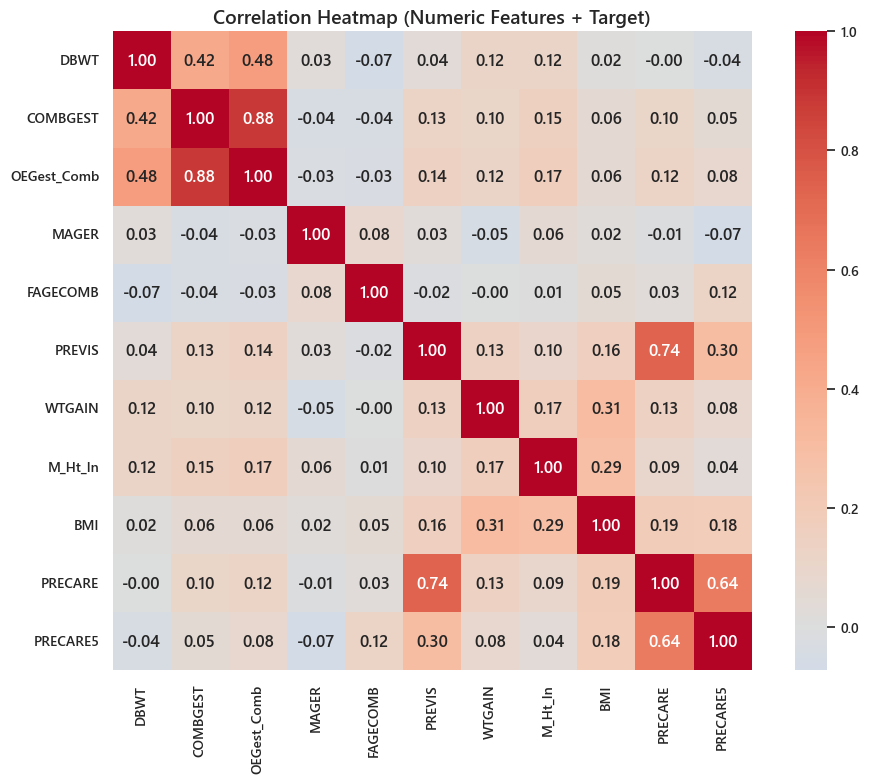

Top absolute correlations:


correlation
COMBGEST OEGest_Comb     0.883057
PREVIS   PRECARE         0.736817
PRECARE  PRECARE5        0.635518
DBWT     OEGest_Comb     0.476590
         COMBGEST        0.418890

Commentary:
The strongest positive relationships typically involve gestation and birth weight-related variables, which is expected clinically.
If two predictors are highly correlated (e.g., alternate gestation encodings), regularized models or feature selection can reduce multicollinearity.


In [47]:
# 1.4 Correlation matrix + heatmap + commentary
corr_cols = [c for c in ["DBWT", "COMBGEST", "OEGest_Comb", "MAGER", "FAGECOMB", "PREVIS", "WTGAIN", "M_Ht_In", "BMI", "PRECARE", "PRECARE5"] if c in eda_sample.columns]
corr_df = eda_sample[corr_cols].apply(pd.to_numeric, errors="coerce")
corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (Numeric Features + Target)")
plt.tight_layout()
plt.show()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().sort_values(key=lambda s: s.abs(), ascending=False)
top_pairs = upper.head(5)

print("Top absolute correlations:")
display(top_pairs.rename("correlation").to_frame())

print("Commentary:")
print("The strongest positive relationships typically involve gestation and birth weight-related variables, which is expected clinically.")
print("If two predictors are highly correlated (e.g., alternate gestation encodings), regularized models or feature selection can reduce multicollinearity.")

### Cleft Lip/Palate Prediction Feasibility
Yes — this dataset can support predicting babies with cleft lip/palate at the **record level** and estimating total U.S. case counts by aggregating predicted probabilities.

- `CA_CLEFT`: cleft lip with/without cleft palate (Y/N/U)
- `CA_CLPAL`: cleft palate alone (Y/N/U)
- We define a case as either field being `Y`.

,metric,value
0,Total births,"3,638,436"
1,Observed cleft cases,"2,535"
2,Prevalence (%),0.0697
3,"Prevalence per 10,000 births",6.97


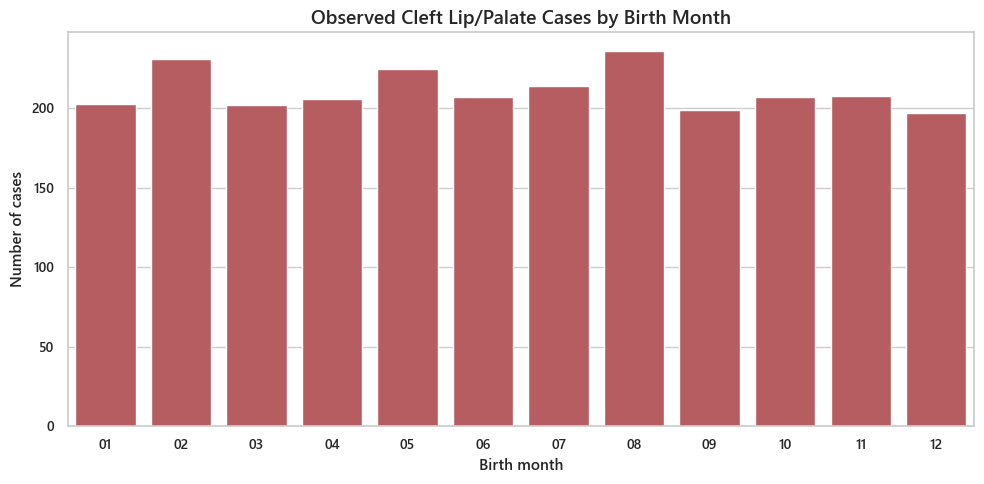

Modeling note: This is a rare-event classification problem. Train a classifier for cleft_case, then aggregate predicted probabilities to estimate case counts.
Forecasting future U.S. counts requires additional years of data (time series), not only one cross-section.


In [48]:
# Cleft case definition and baseline counts
for c in ["CA_CLEFT", "CA_CLPAL", "DOB_MM"]:
    if c in nat2024us.columns:
        nat2024us[c] = nat2024us[c].astype("string").str.strip()

nat2024us["cleft_case"] = ((nat2024us["CA_CLEFT"] == "Y") | (nat2024us["CA_CLPAL"] == "Y")).astype(int)

total_births = len(nat2024us)
total_cases = int(nat2024us["cleft_case"].sum())
prevalence_pct = total_cases / total_births * 100
prevalence_per_10k = total_cases / total_births * 10000

summary = pd.DataFrame({
    "metric": ["Total births", "Observed cleft cases", "Prevalence (%)", "Prevalence per 10,000 births"],
    "value": [f"{total_births:,}", f"{total_cases:,}", round(prevalence_pct, 4), round(prevalence_per_10k, 2)]
})

display(summary)

monthly_cases = (
    nat2024us.groupby("DOB_MM", dropna=False)["cleft_case"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "cases", "count": "births"})
    .reset_index()
    .sort_values("DOB_MM")
)
monthly_cases["cases_per_10k"] = monthly_cases["cases"] / monthly_cases["births"] * 10000

plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_cases, x="DOB_MM", y="cases", color="#C44E52")
plt.title("Observed Cleft Lip/Palate Cases by Birth Month")
plt.xlabel("Birth month")
plt.ylabel("Number of cases")
plt.tight_layout()
plt.show()

print("Modeling note: This is a rare-event classification problem. Train a classifier for cleft_case, then aggregate predicted probabilities to estimate case counts.")
print("Forecasting future U.S. counts requires additional years of data (time series), not only one cross-section.")

## Part 1: Descriptive Analytics for Cleft Case Prediction
This final Part 1 section is aligned to your objective: predicting U.S. cases of babies with cleft lip/palate using `cleft_case` as the dependent variable.

### 1.1 Dataset Introduction
- **Dataset contents/source:** U.S. natality microdata (NCHS public-use 2024 fixed-width file), one row per birth record.
- **Target (dependent variable):** `cleft_case` = 1 if `CA_CLEFT == 'Y'` or `CA_CLPAL == 'Y'`; otherwise 0.
- **Why impactful:** Predicting cleft-case risk supports neonatal care planning and maternal-child public health resource allocation.
- **Task framing:** Rare-event **classification** at record level; national case burden can be estimated by aggregating predicted probabilities.

In [49]:
# Part 1 (cleft target) setup and basic stats
for col in ["CA_CLEFT", "CA_CLPAL"]:
    nat2024us[col] = nat2024us[col].astype("string").str.strip()

nat2024us["cleft_case"] = ((nat2024us["CA_CLEFT"] == "Y") | (nat2024us["CA_CLPAL"] == "Y")).astype(int)
target = "cleft_case"

feature_types = pd.DataFrame({
    "feature": nat2024us.columns,
    "numeric_ratio": [pd.to_numeric(nat2024us[c], errors="coerce").notna().mean() for c in nat2024us.columns]
})
n_numeric_like = int((feature_types["numeric_ratio"] >= 0.98).sum())
n_categorical_like = int((feature_types["numeric_ratio"] < 0.98).sum())

intro_stats_cleft = pd.DataFrame({
    "metric": ["Rows", "Features", "Numeric-like features", "Categorical-like features", "Target", "Positive cases", "Positive rate (%)"],
    "value": [
        f"{len(nat2024us):,}",
        nat2024us.shape[1],
        n_numeric_like,
        n_categorical_like,
        target,
        int(nat2024us[target].sum()),
        round(nat2024us[target].mean() * 100, 4)
    ]
})
display(intro_stats_cleft)

,metric,value
0,Rows,"3,638,436"
1,Features,90
2,Numeric-like features,75
3,Categorical-like features,15
4,Target,cleft_case
5,Positive cases,2535
6,Positive rate (%),0.0697


### 1.2 Target Distribution (5 points)
Target is binary (`cleft_case`), so we use a class-frequency bar chart and assess class imbalance.

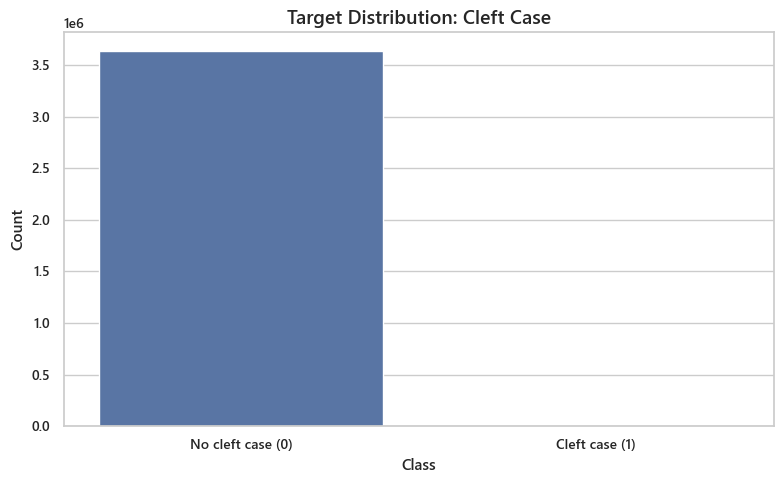

Interpretation: Positive class prevalence is 0.0697% (highly imbalanced).
Class ratio (0:1) is approximately 1434.3:1.
Plan: use stratified splits, class weighting or resampling, and PR-AUC/recall-focused evaluation.


In [50]:
# 1.2 Target distribution (classification)
target_counts = nat2024us[target].value_counts().sort_index()
label_map = {0: "No cleft case (0)", 1: "Cleft case (1)"}
plot_target = pd.DataFrame({
    "class": [label_map.get(i, str(i)) for i in target_counts.index],
    "count": target_counts.values
})

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_target, x="class", y="count", palette=["#4C72B0", "#C44E52"])
plt.title("Target Distribution: Cleft Case")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

pos_rate = nat2024us[target].mean() * 100
imbalance_ratio = (target_counts.get(0, 0) / max(target_counts.get(1, 1), 1))
print(f"Interpretation: Positive class prevalence is {pos_rate:.4f}% (highly imbalanced).")
print(f"Class ratio (0:1) is approximately {imbalance_ratio:.1f}:1.")
print("Plan: use stratified splits, class weighting or resampling, and PR-AUC/recall-focused evaluation.")

### 1.3 Feature Distributions and Relationships
Below are at least four visualizations that highlight non-obvious cleft-risk patterns.
Each plot is followed by a brief interpretation focused on modeling insight.

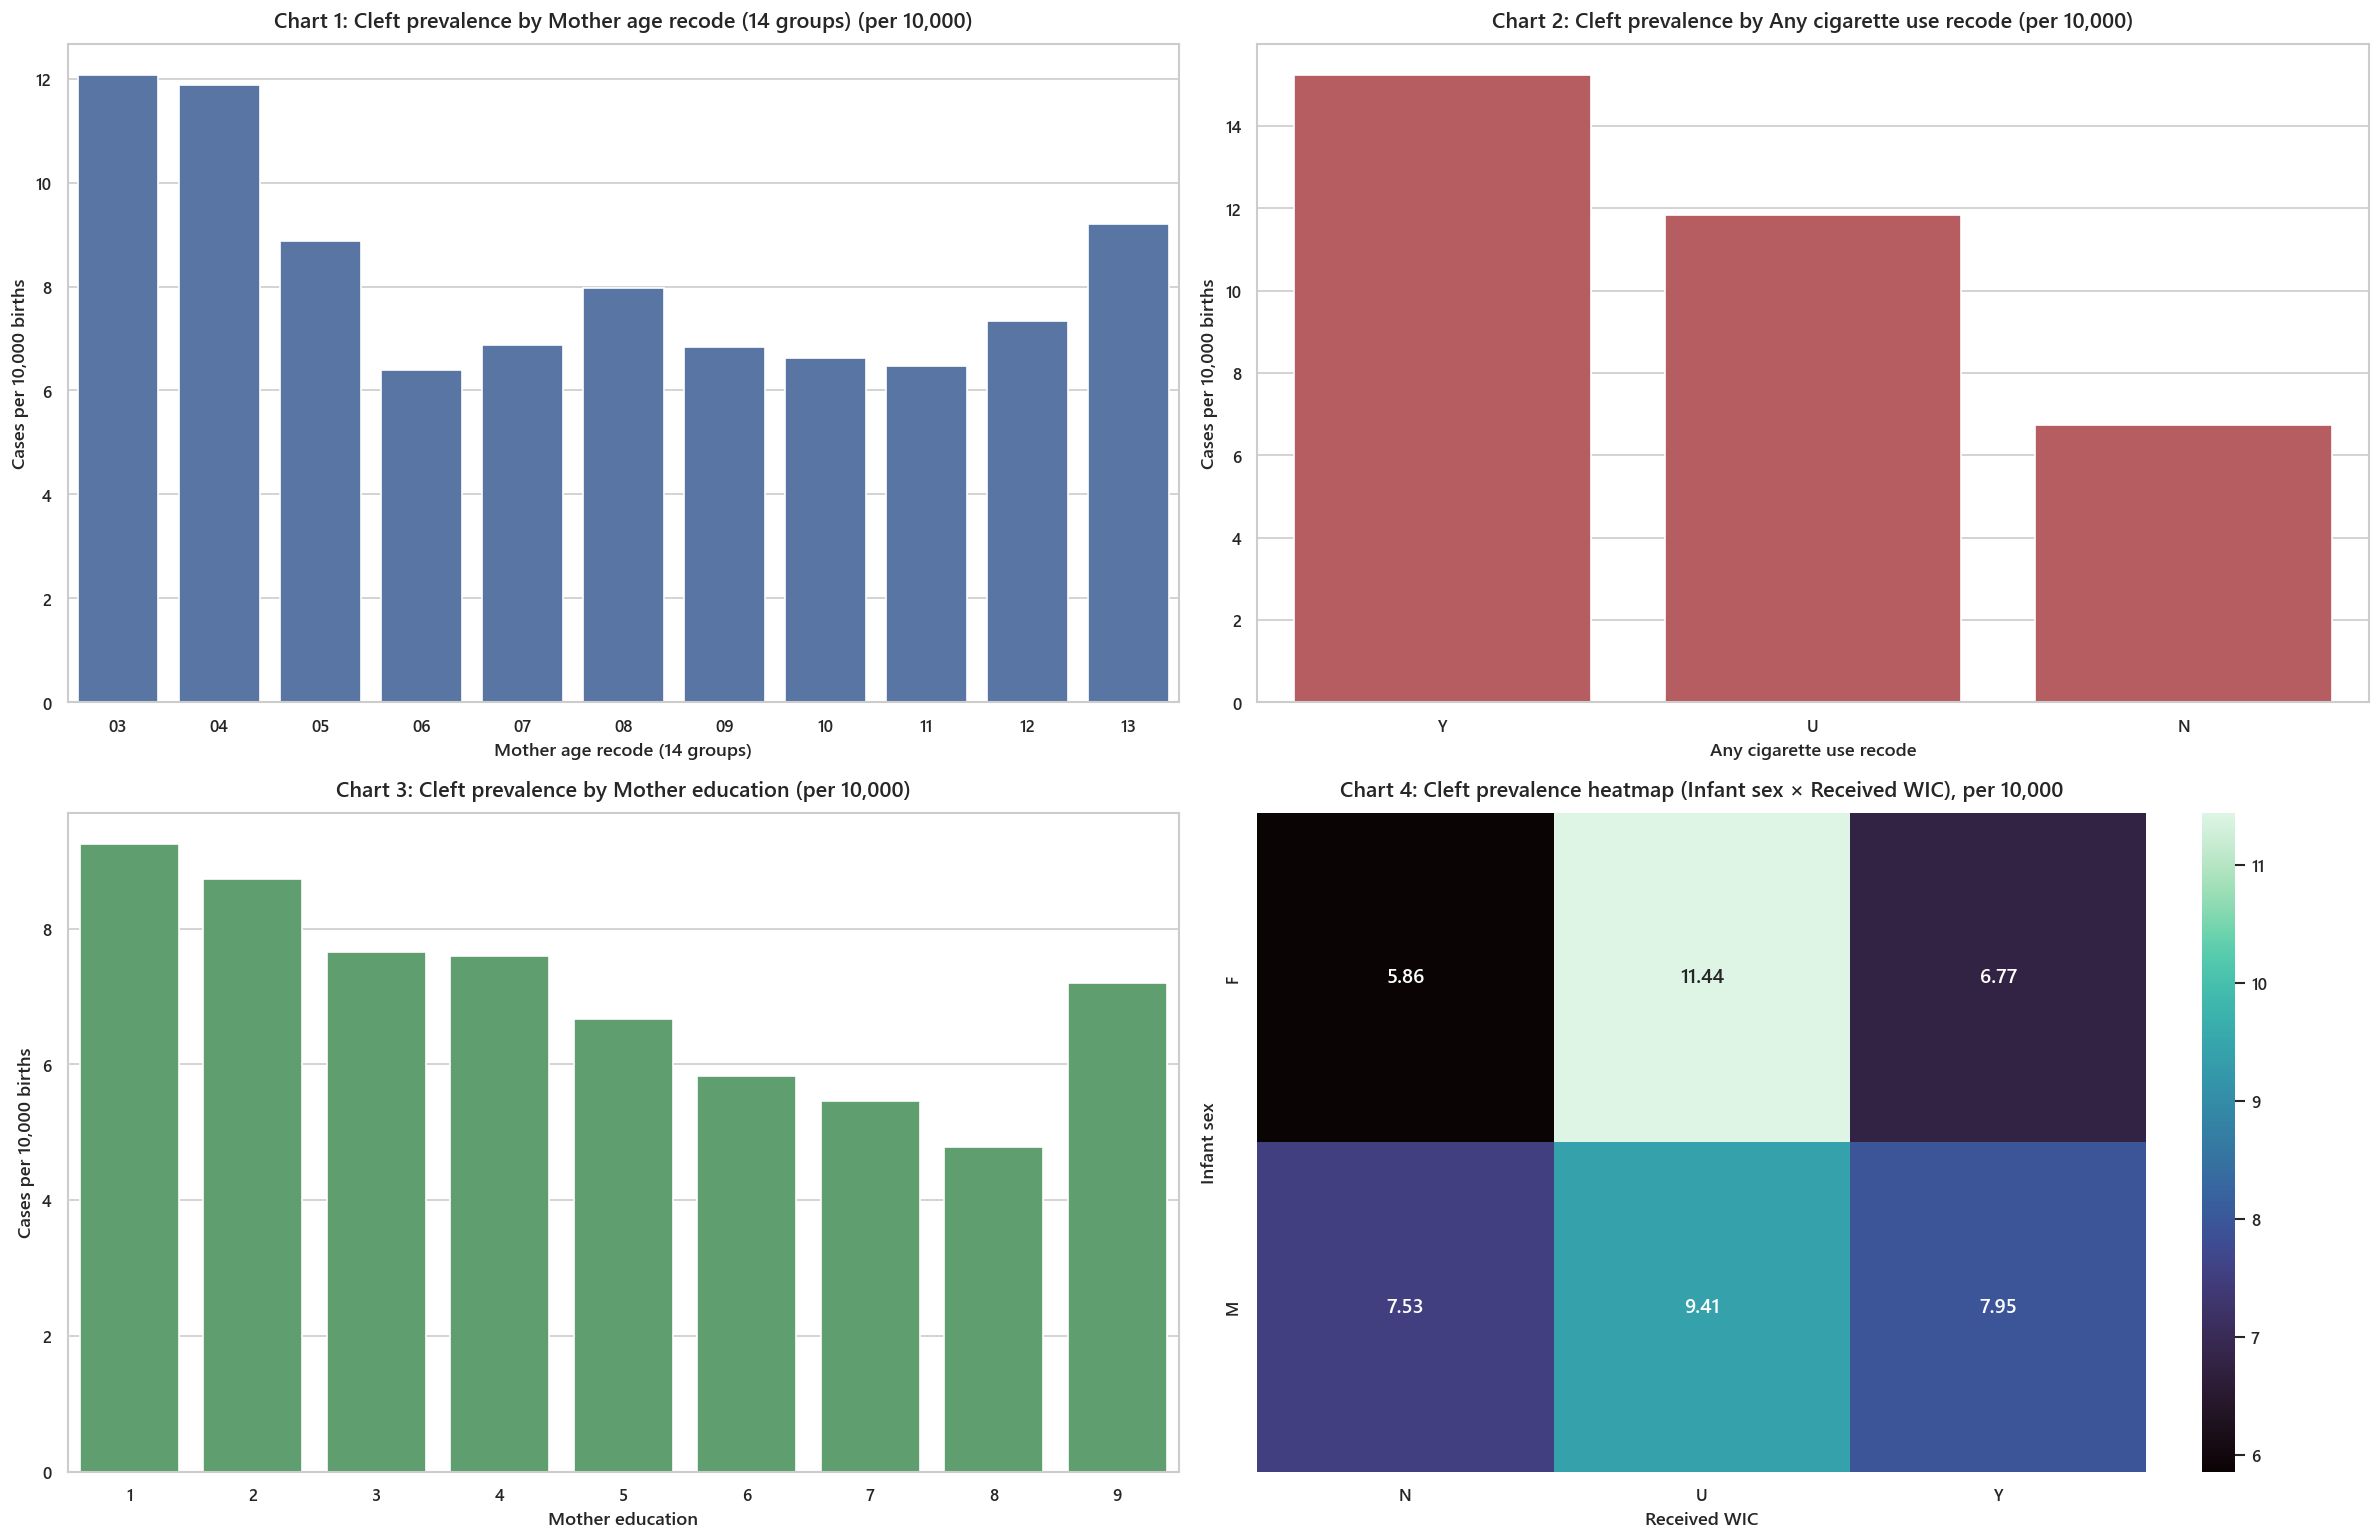

In [51]:
# 1.3 Four cleft-focused visualizations (friendly names + chart-level conclusions)
clf_df = nat2024us.copy()

if "data_dictionary" in globals() and {"feature", "description"}.issubset(data_dictionary.columns):
    friendly_map = dict(zip(data_dictionary["feature"], data_dictionary["description"]))
else:
    friendly_map = {}

def fname(col):
    return friendly_map.get(col, col)

for col in ["MAGER", "PREVIS", "COMBGEST", "BMI"]:
    if col in clf_df.columns:
        clf_df[col] = pd.to_numeric(clf_df[col], errors="coerce")

def prevalence_table(df, group_col, min_n=5000):
    g = (
        df.dropna(subset=[group_col, "cleft_case"])
        .groupby(group_col, as_index=False)
        .agg(cases=("cleft_case", "sum"), births=("cleft_case", "count"))
    )
    g = g[g["births"] >= min_n].copy()
    g["prev_per_10k"] = g["cases"] / g["births"] * 10000
    return g.sort_values("prev_per_10k", ascending=False)

age_prev = prevalence_table(clf_df, "MAGER14", min_n=2000)
smoke_prev = prevalence_table(clf_df, "CIG_REC", min_n=2000)
educ_prev = prevalence_table(clf_df, "MEDUC", min_n=2000)

heat_df = (
    clf_df.dropna(subset=["SEX", "WIC", "cleft_case"])
    .groupby(["SEX", "WIC"], as_index=False)
    .agg(cases=("cleft_case", "sum"), births=("cleft_case", "count"))
)
heat_df["prev_per_10k"] = heat_df["cases"] / heat_df["births"] * 10000
heat_pivot = heat_df.pivot(index="SEX", columns="WIC", values="prev_per_10k")

fig, axes = plt.subplots(2, 2, figsize=(20, 13), dpi=120)

# Chart 1
sns.barplot(data=age_prev.sort_values("MAGER14"), x="MAGER14", y="prev_per_10k", ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title(f"Chart 1: Cleft prevalence by {fname('MAGER14')} (per 10,000)", fontsize=13, pad=10)
axes[0, 0].set_xlabel(fname("MAGER14"))
axes[0, 0].set_ylabel("Cases per 10,000 births")

# Chart 2
sns.barplot(data=smoke_prev, x="CIG_REC", y="prev_per_10k", ax=axes[0, 1], color="#C44E52")
axes[0, 1].set_title(f"Chart 2: Cleft prevalence by {fname('CIG_REC')} (per 10,000)", fontsize=13, pad=10)
axes[0, 1].set_xlabel(fname("CIG_REC"))
axes[0, 1].set_ylabel("Cases per 10,000 births")

# Chart 3
sns.barplot(data=educ_prev.sort_values("MEDUC"), x="MEDUC", y="prev_per_10k", ax=axes[1, 0], color="#55A868")
axes[1, 0].set_title(f"Chart 3: Cleft prevalence by {fname('MEDUC')} (per 10,000)", fontsize=13, pad=10)
axes[1, 0].set_xlabel(fname("MEDUC"))
axes[1, 0].set_ylabel("Cases per 10,000 births")

# Chart 4
sns.heatmap(heat_pivot, annot=True, fmt=".2f", cmap="mako", ax=axes[1, 1])
axes[1, 1].set_title(f"Chart 4: Cleft prevalence heatmap ({fname('SEX')} × {fname('WIC')}), per 10,000", fontsize=13, pad=10)
axes[1, 1].set_xlabel(fname("WIC"))
axes[1, 1].set_ylabel(fname("SEX"))

plt.tight_layout()
plt.show()

In [52]:
# 1.3 Interpretation (chart name + brief observation/conclusion)
if "data_dictionary" in globals() and {"feature", "description"}.issubset(data_dictionary.columns):
    friendly_map = dict(zip(data_dictionary["feature"], data_dictionary["description"]))
else:
    friendly_map = {}

def fname(col):
    return friendly_map.get(col, col)

print(f"Chart 1 — Cleft prevalence by {fname('MAGER14')}:")
print("Observation: prevalence differs across age-recode groups rather than staying flat.")
print(f"Conclusion: age profile matters for risk stratification (range {age_prev['prev_per_10k'].min():.2f} to {age_prev['prev_per_10k'].max():.2f} per 10,000).\n")

print(f"Chart 2 — Cleft prevalence by {fname('CIG_REC')}:")
print("Observation: smoking-recode categories show visible prevalence separation.")
print("Conclusion: tobacco-related behavior should be retained as a predictive feature and evaluated with confounder controls.\n")

print(f"Chart 3 — Cleft prevalence by {fname('MEDUC')}:")
print("Observation: maternal education groups show a gradient in prevalence levels.")
print("Conclusion: socioeconomic context contributes signal for modeling, though this remains associative rather than causal.\n")

print(f"Chart 4 — Heatmap of {fname('SEX')} × {fname('WIC')}:")
print("Observation: joint strata show heterogeneous prevalence values that are not captured by a single variable view.")
print("Conclusion: interaction-capable models or explicit interaction terms are justified for Part 2.")

Chart 1 — Cleft prevalence by Mother age recode (14 groups):
Observation: prevalence differs across age-recode groups rather than staying flat.
Conclusion: age profile matters for risk stratification (range 6.40 to 12.07 per 10,000).

Chart 2 — Cleft prevalence by Any cigarette use recode:
Observation: smoking-recode categories show visible prevalence separation.
Conclusion: tobacco-related behavior should be retained as a predictive feature and evaluated with confounder controls.

Chart 3 — Cleft prevalence by Mother education:
Observation: maternal education groups show a gradient in prevalence levels.
Conclusion: socioeconomic context contributes signal for modeling, though this remains associative rather than causal.

Chart 4 — Heatmap of Infant sex × Received WIC:
Observation: joint strata show heterogeneous prevalence values that are not captured by a single variable view.
Conclusion: interaction-capable models or explicit interaction terms are justified for Part 2.


### 1.3 Visualization Checklist
This subsection covers the required visualization types:
1) Histogram/boxplot broken down by target,
2) Violin plot across categories,
3) Pair plot for key numeric features,
4) Bar chart of categorical feature vs target.

In [53]:
# Prep for required plot types (friendly names + balanced visualization sample)
if "data_dictionary" in globals() and {"feature", "description"}.issubset(data_dictionary.columns):
    friendly_map = dict(zip(data_dictionary["feature"], data_dictionary["description"]))
else:
    friendly_map = {}

def fname(col):
    return friendly_map.get(col, col)

# Vivid style settings for this section
vivid_palette = ["#0078D4", "#E81123", "#FF8C00", "#00B7C3", "#7B61FF", "#00CC6A", "#C239B3", "#F7630C"]
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette=vivid_palette,
    rc={
        "font.family": "Segoe UI",
        "font.weight": "semibold",
        "axes.labelsize": 10,
        "axes.titlesize": 13,
        "axes.labelweight": "semibold",
        "axes.titleweight": "semibold",
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 10,
    },
)
plt.rcParams["font.family"] = "Segoe UI"
plt.rcParams["font.weight"] = "semibold"

# Mother education codebook
meduc_map = {
    "1": "8th grade or less",
    "2": "9th-12th, no diploma",
    "3": "High school graduate/GED",
    "4": "Some college, no degree",
    "5": "Associate degree",
    "6": "Bachelor's degree",
    "7": "Master's degree",
    "8": "Doctorate/professional degree",
    "9": "Unknown"
}

for col in ["COMBGEST", "BMI", "MAGER", "PREVIS"]:
    if col in nat2024us.columns:
        nat2024us[col] = pd.to_numeric(nat2024us[col], errors="coerce")

for col in ["MEDUC", "WIC"]:
    if col in nat2024us.columns:
        nat2024us[col] = nat2024us[col].astype("string").str.strip()

nat2024us["cleft_case"] = pd.to_numeric(nat2024us["cleft_case"], errors="coerce").fillna(0).astype(int)

pos_df = nat2024us[nat2024us["cleft_case"] == 1]
neg_df = nat2024us[nat2024us["cleft_case"] == 0].sample(min(len(pos_df) * 10, 50000), random_state=42)
vis_df = pd.concat([pos_df, neg_df], axis=0).copy()
vis_df["target_label"] = vis_df["cleft_case"].map({0: "No cleft case", 1: "Cleft case"})
print(f"Visualization sample size: {len(vis_df):,} (positives={int((vis_df['cleft_case']==1).sum()):,}, negatives={int((vis_df['cleft_case']==0).sum()):,})")

Visualization sample size: 27,885 (positives=2,535, negatives=25,350)


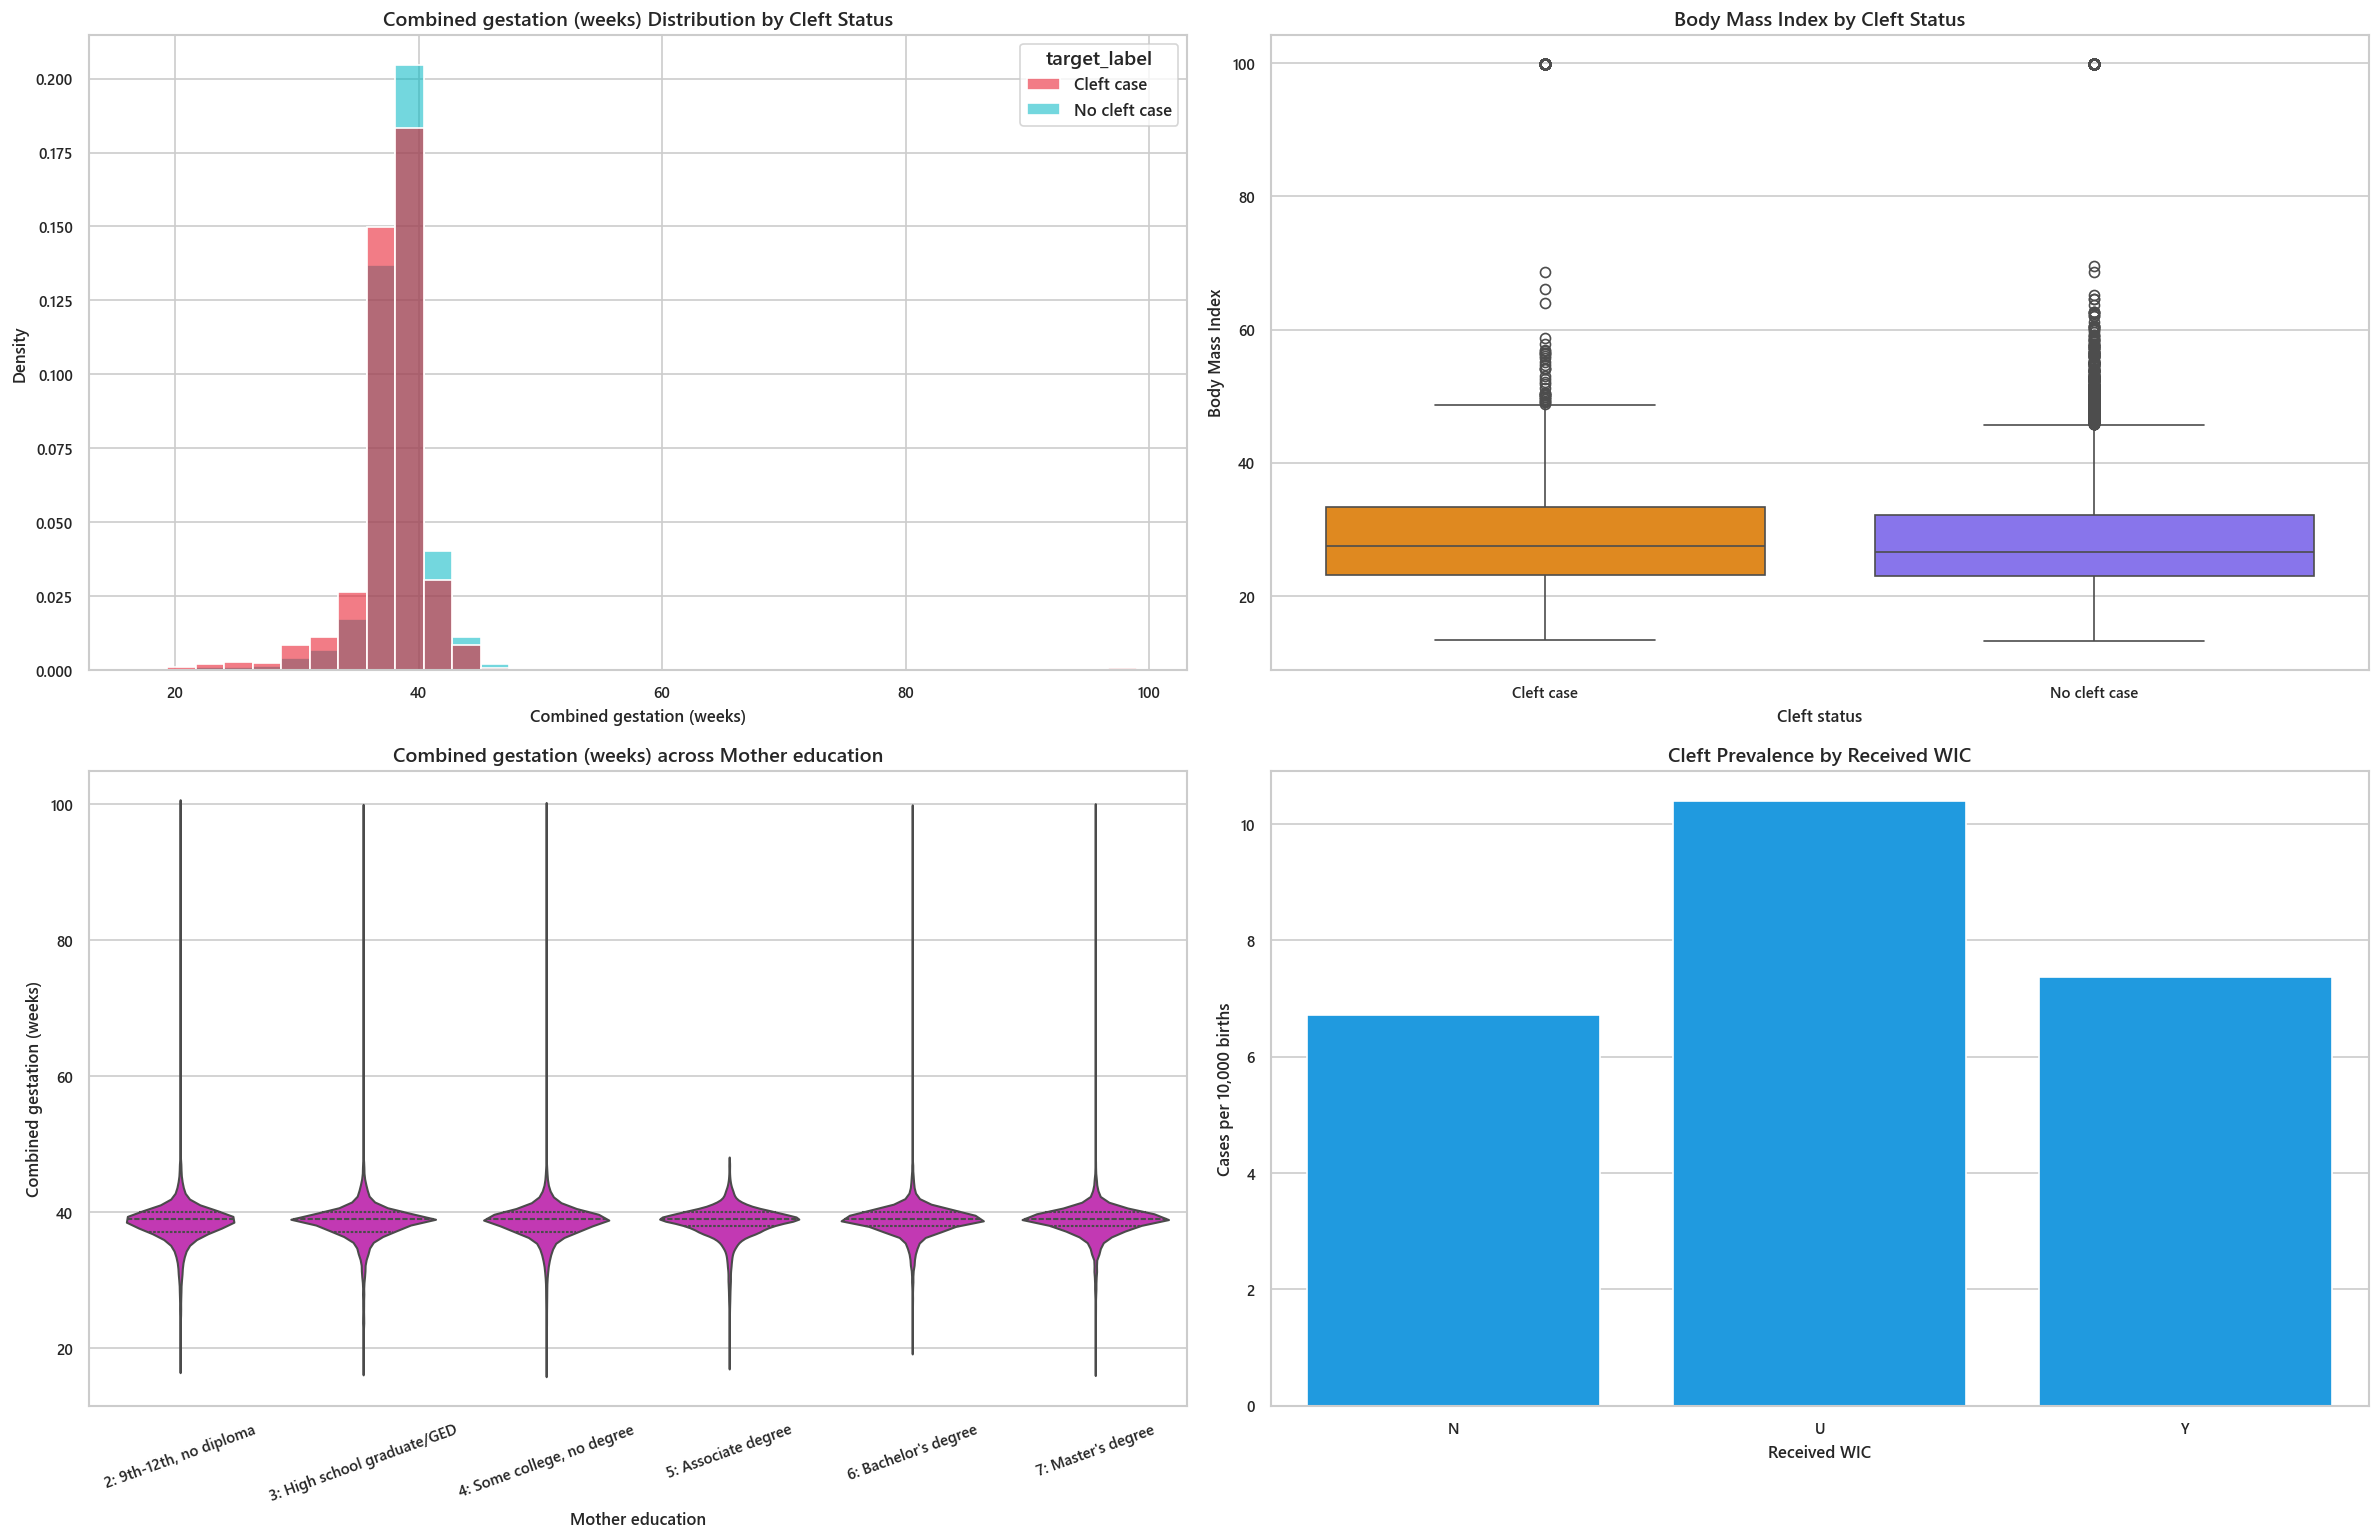

Mother education codes shown in charts:


,MEDUC code,Description
0,2,"9th-12th, no diploma"
1,3,High school graduate/GED
2,4,"Some college, no degree"
3,5,Associate degree
4,6,Bachelor's degree
5,7,Master's degree


Interpretation (Gestation histogram): Gestation distributions differ across cleft classes, with density shifts rather than a clean split.
This suggests gestation contributes signal, but not enough alone to classify cases.
Interpretation (BMI boxplot): BMI distributions overlap strongly between classes, with modest differences in center/spread.
BMI is likely a weak standalone predictor that may still help in combination with other features.
Interpretation (Gestation by education violin): Gestation varies across maternal education groups, indicating subgroup heterogeneity.
These subgroup differences support including maternal sociodemographic context in modeling.
Interpretation (WIC bar chart): Cleft prevalence per 10,000 births varies by WIC category.
Categorical access/eligibility indicators may carry useful risk stratification information.


In [54]:
# Histogram / boxplot / violin / bar chart
fig, axes = plt.subplots(2, 2, figsize=(20, 13), dpi=120)

# 1) Histogram by target
hist_df = vis_df.dropna(subset=["COMBGEST", "target_label"])
hue_palette = {"No cleft case": "#00B7C3", "Cleft case": "#E81123"}
sns.histplot(
    data=hist_df,
    x="COMBGEST",
    hue="target_label",
    palette=hue_palette,
    bins=35,
    stat="density",
    common_norm=False,
    alpha=0.55,
    ax=axes[0, 0]
)
axes[0, 0].set_title(f"{fname('COMBGEST')} Distribution by Cleft Status", fontsize=12, fontweight="semibold")
axes[0, 0].set_xlabel(fname("COMBGEST"), fontsize=10, fontweight="semibold")
axes[0, 0].set_ylabel("Density", fontsize=10, fontweight="semibold")

# 2) Boxplot by target
box_df = vis_df.dropna(subset=["BMI", "target_label"])
sns.boxplot(data=box_df, x="target_label", y="BMI", hue="target_label", dodge=False, palette=["#FF8C00", "#7B61FF"], legend=False, ax=axes[0, 1])
axes[0, 1].set_title(f"{fname('BMI')} by Cleft Status", fontsize=12, fontweight="semibold")
axes[0, 1].set_xlabel("Cleft status", fontsize=10, fontweight="semibold")
axes[0, 1].set_ylabel(fname("BMI"), fontsize=10, fontweight="semibold")

# 3) Violin across categories (Mother education with labels)
violin_df = vis_df.dropna(subset=["MEDUC", "COMBGEST"])
top_meduc = violin_df["MEDUC"].value_counts().head(6).index
violin_df = violin_df[violin_df["MEDUC"].isin(top_meduc)].copy()
violin_df["MEDUC_label"] = violin_df["MEDUC"].map(lambda x: f"{x}: {meduc_map.get(str(x), 'Unknown')}")
order_labels = [f"{c}: {meduc_map.get(str(c), 'Unknown')}" for c in sorted(top_meduc, key=lambda x: int(x) if str(x).isdigit() else 99)]
sns.violinplot(data=violin_df, x="MEDUC_label", y="COMBGEST", inner="quartile", order=order_labels, color="#C239B3", saturation=1, ax=axes[1, 0])
axes[1, 0].set_title(f"{fname('COMBGEST')} across {fname('MEDUC')}", fontsize=12, fontweight="semibold")
axes[1, 0].set_xlabel(fname("MEDUC"), fontsize=10, fontweight="semibold")
axes[1, 0].set_ylabel(fname("COMBGEST"), fontsize=10, fontweight="semibold")
axes[1, 0].tick_params(axis="x", rotation=20)

# 4) Bar chart categorical vs target
bar_df = nat2024us.dropna(subset=["WIC", "cleft_case"]).groupby("WIC", as_index=False).agg(cases=("cleft_case", "sum"), births=("cleft_case", "count"))
bar_df["prev_per_10k"] = bar_df["cases"] / bar_df["births"] * 10000
sns.barplot(data=bar_df, x="WIC", y="prev_per_10k", color="#00A3FF", ax=axes[1, 1])
axes[1, 1].set_title(f"Cleft Prevalence by {fname('WIC')}", fontsize=12, fontweight="semibold")
axes[1, 1].set_xlabel(fname("WIC"), fontsize=10, fontweight="semibold")
axes[1, 1].set_ylabel("Cases per 10,000 births", fontsize=10, fontweight="semibold")

for ax in axes.flat:
    ax.tick_params(axis="both", labelsize=9)

plt.tight_layout()
plt.show()

shown_codes = sorted(set(top_meduc), key=lambda x: int(x) if str(x).isdigit() else 99)
meduc_lookup = pd.DataFrame({
    "MEDUC code": shown_codes,
    "Description": [meduc_map.get(str(c), "Unknown") for c in shown_codes]
})
print("Mother education codes shown in charts:")
display(meduc_lookup)

print("Interpretation (Gestation histogram): Gestation distributions differ across cleft classes, with density shifts rather than a clean split.")
print("This suggests gestation contributes signal, but not enough alone to classify cases.")
print("Interpretation (BMI boxplot): BMI distributions overlap strongly between classes, with modest differences in center/spread.")
print("BMI is likely a weak standalone predictor that may still help in combination with other features.")
print("Interpretation (Gestation by education violin): Gestation varies across maternal education groups, indicating subgroup heterogeneity.")
print("These subgroup differences support including maternal sociodemographic context in modeling.")
print("Interpretation (WIC bar chart): Cleft prevalence per 10,000 births varies by WIC category.")
print("Categorical access/eligibility indicators may carry useful risk stratification information.")

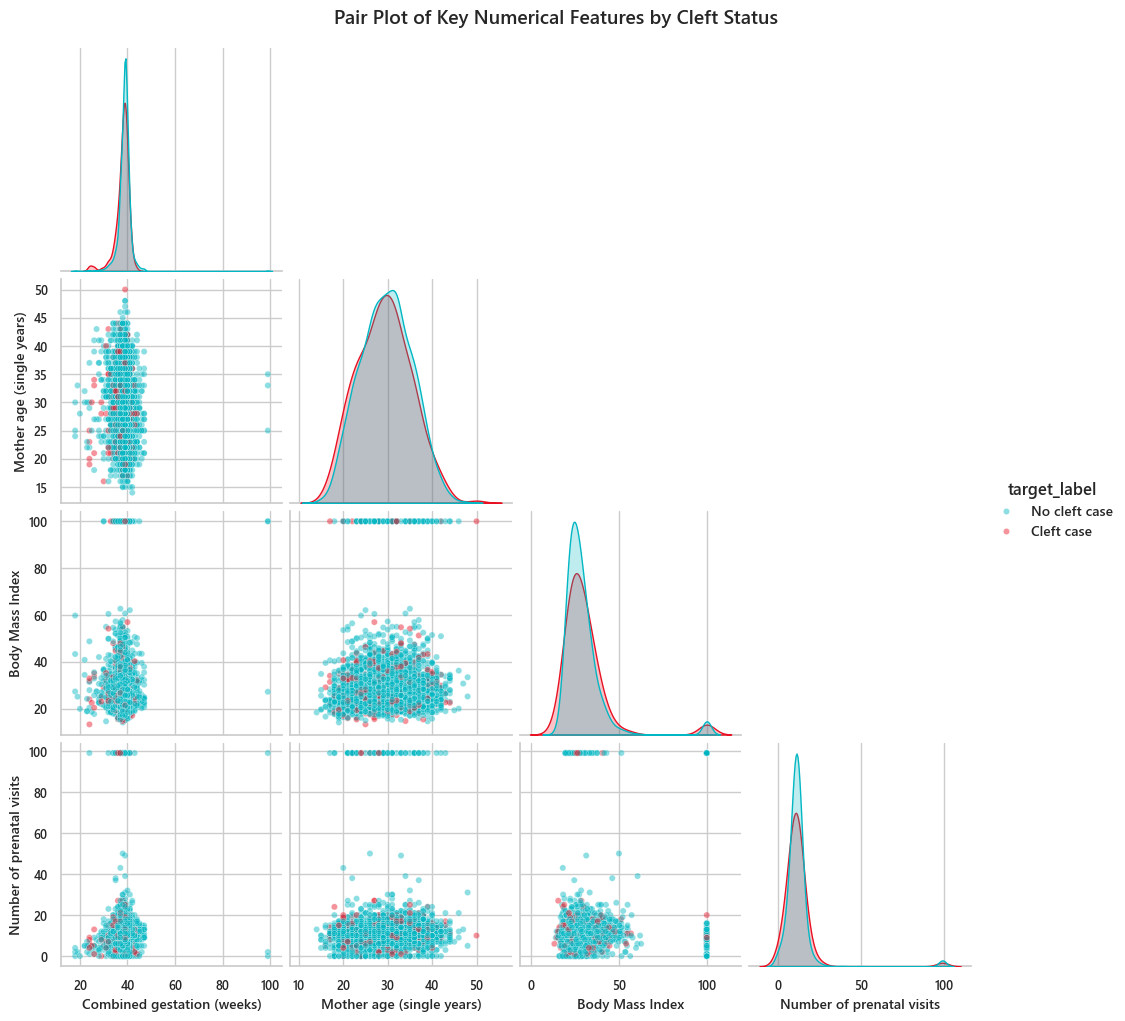

Interpretation (Pair plot): Pairwise feature relationships show broad overlap between classes, which is expected for a rare outcome.
Model accuracy will likely come from combining multiple weak patterns and interactions rather than one dominant separator.


In [55]:
# Pair plot for key numerical features
pair_cols = [c for c in ["COMBGEST", "MAGER", "BMI", "PREVIS", "cleft_case"] if c in vis_df.columns]
pair_df = vis_df[pair_cols].dropna().copy()
pair_df = pair_df.sample(min(4000, len(pair_df)), random_state=42)
pair_df["target_label"] = pair_df["cleft_case"].map({0: "No cleft case", 1: "Cleft case"})

rename_map = {c: fname(c) for c in pair_cols if c != "cleft_case"}
pair_df = pair_df.rename(columns=rename_map)
pair_vars = [rename_map[c] for c in pair_cols if c != "cleft_case"]

pair_palette = {"No cleft case": "#00B7C3", "Cleft case": "#E81123"}
g = sns.pairplot(
    pair_df,
    vars=pair_vars,
    hue="target_label",
    palette=pair_palette,
    corner=True,
    plot_kws={"alpha": 0.45, "s": 20},
    diag_kws={"common_norm": False}
)
g.fig.suptitle("Pair Plot of Key Numerical Features by Cleft Status", y=1.02, fontsize=14, fontweight="semibold")

for row_axes in g.axes:
    for ax in row_axes:
        if ax is not None:
            ax.tick_params(axis="both", labelsize=9)
            ax.xaxis.label.set_size(10)
            ax.yaxis.label.set_size(10)
            ax.xaxis.label.set_weight("semibold")
            ax.yaxis.label.set_weight("semibold")

plt.show()

print("Interpretation (Pair plot): Pairwise feature relationships show broad overlap between classes, which is expected for a rare outcome.")
print("Model accuracy will likely come from combining multiple weak patterns and interactions rather than one dominant separator.")

### 1.4 Correlation Heatmap
We compute a numeric correlation matrix including `cleft_case` and comment on strongest associations relevant for feature selection and multicollinearity checks.

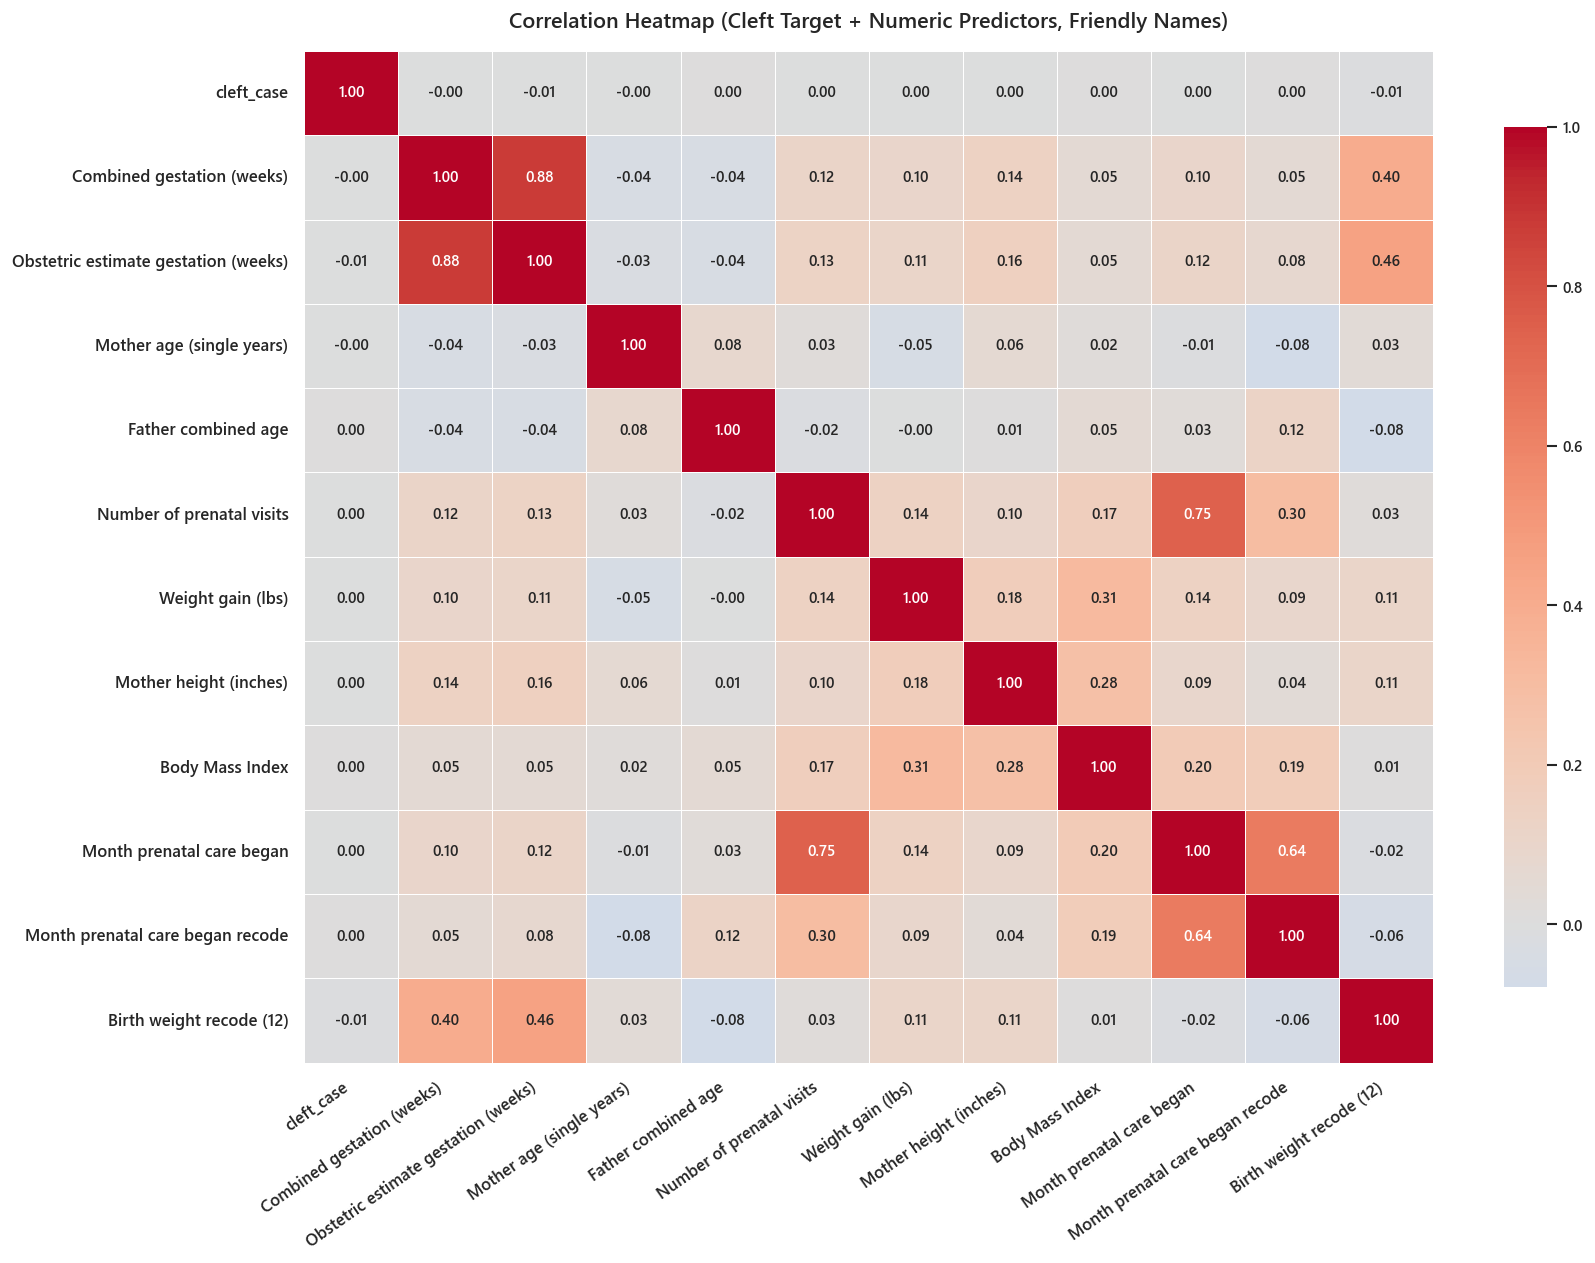

,feature_1,feature_1_name,feature_2,feature_2_name,correlation
0,COMBGEST,Combined gestation (weeks),OEGest_Comb,Obstetric estimate gestation (weeks),0.878057
1,PREVIS,Number of prenatal visits,PRECARE,Month prenatal care began,0.746162
2,PRECARE,Month prenatal care began,PRECARE5,Month prenatal care began recode,0.637209
3,OEGest_Comb,Obstetric estimate gestation (weeks),BWTR12,Birth weight recode (12),0.460792
4,COMBGEST,Combined gestation (weeks),BWTR12,Birth weight recode (12),0.403625


Strongest correlations with cleft_case:


,feature,feature_name,corr_with_cleft_case
0,BWTR12,Birth weight recode (12),-0.007871
1,OEGest_Comb,Obstetric estimate gestation (weeks),-0.005331
2,COMBGEST,Combined gestation (weeks),-0.004806
3,PRECARE5,Month prenatal care began recode,0.003121
4,BMI,Body Mass Index,0.003109


Interpretation:
The strongest pairwise relationship is between Combined gestation (weeks) and Obstetric estimate gestation (weeks) (r=0.88), indicating potential redundancy.
The top linear association with cleft_case is Birth weight recode (12) (r=-0.008), but the magnitude remains modest, which is typical for rare-event targets.
Modeling implication: keep these features as useful signals, but rely on multivariate and possibly non-linear models with interaction effects rather than a single-feature rule.


In [56]:
# 1.4 Correlation heatmap + strongest associations
corr_features = [c for c in ["cleft_case", "COMBGEST", "OEGest_Comb", "MAGER", "FAGECOMB", "PREVIS", "WTGAIN", "M_Ht_In", "BMI", "PRECARE", "PRECARE5", "BWTR12"] if c in nat2024us.columns]
corr_data = nat2024us[corr_features].copy()
for c in corr_features:
    corr_data[c] = pd.to_numeric(corr_data[c], errors="coerce")

corr_matrix_cleft = corr_data.corr()

if "data_dictionary" in globals() and {"feature", "description"}.issubset(data_dictionary.columns):
    friendly_map = dict(zip(data_dictionary["feature"], data_dictionary["description"]))
else:
    friendly_map = {c: c for c in corr_features}

friendly_labels = [friendly_map.get(c, c) for c in corr_matrix_cleft.columns]
corr_matrix_named = corr_matrix_cleft.copy()
corr_matrix_named.columns = friendly_labels
corr_matrix_named.index = friendly_labels

fig_w = max(14, 0.9 * len(friendly_labels) + 6)
fig_h = max(10, 0.8 * len(friendly_labels) + 4)
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=120)
sns.heatmap(
    corr_matrix_named,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False,
    linewidths=0.5,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.85},
    ax=ax
)
ax.set_title("Correlation Heatmap (Cleft Target + Numeric Predictors, Friendly Names)", pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
fig.subplots_adjust(left=0.28, bottom=0.30, right=0.98, top=0.92)
plt.show()

pairs = corr_matrix_cleft.where(np.triu(np.ones(corr_matrix_cleft.shape), k=1).astype(bool)).stack().sort_values(key=lambda s: s.abs(), ascending=False)
top5 = pairs.head(5).reset_index()
top5.columns = ["feature_1", "feature_2", "correlation"]
top5["feature_1_name"] = top5["feature_1"].map(friendly_map).fillna(top5["feature_1"])
top5["feature_2_name"] = top5["feature_2"].map(friendly_map).fillna(top5["feature_2"])
display(top5[["feature_1", "feature_1_name", "feature_2", "feature_2_name", "correlation"]])

target_corr = corr_matrix_cleft["cleft_case"].drop("cleft_case").sort_values(key=lambda s: s.abs(), ascending=False).head(5).reset_index()
target_corr.columns = ["feature", "corr_with_cleft_case"]
target_corr["feature_name"] = target_corr["feature"].map(friendly_map).fillna(target_corr["feature"])
print("Strongest correlations with cleft_case:")
display(target_corr[["feature", "feature_name", "corr_with_cleft_case"]])

# Added interpretation block for rubric-style discussion
top_pair = top5.iloc[0]
top_target = target_corr.iloc[0]
print("Interpretation:")
print(f"The strongest pairwise relationship is between {top_pair['feature_1_name']} and {top_pair['feature_2_name']} (r={top_pair['correlation']:.2f}), indicating potential redundancy.")
print(f"The top linear association with cleft_case is {top_target['feature_name']} (r={top_target['corr_with_cleft_case']:.3f}), but the magnitude remains modest, which is typical for rare-event targets.")
print("Modeling implication: keep these features as useful signals, but rely on multivariate and possibly non-linear models with interaction effects rather than a single-feature rule.")

## Part 2: Predictive Analytics
This section builds, tunes, and compares classification models for `cleft_case` using a 70/30 train-test split and cross-validation.
All random operations use `random_state=42`.

In [57]:
# Part 2 imports and helpers
import time
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
    )

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

try:
    import tensorflow as tf
    from tensorflow import keras
    from sklearn.utils.class_weight import compute_class_weight
    HAS_TF = True
except Exception:
    HAS_TF = False

def classification_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }

def show_metrics(model_name, metrics_dict):
    print(f"{model_name} test metrics")
    for k, v in metrics_dict.items():
        print(f"  {k}: {v:.4f}")

def find_best_f1_threshold(y_true, y_prob):
    # Choose the threshold on validation probabilities that maximizes F1.
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5, 0.0
    f1_scores = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
    best_idx = int(np.nanargmax(f1_scores))
    return float(thresholds[best_idx]), float(f1_scores[best_idx])

def find_recall_first_threshold(y_true, y_prob, target_recall=0.80):
    # Prioritize recall for rare-event screening, then maximize precision among feasible thresholds.
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5, 0.0, 0.0, False

    p = precision[:-1]
    r = recall[:-1]
    valid = np.where(r >= target_recall)[0]

    if len(valid) > 0:
        # Among thresholds meeting recall target, pick the one with highest precision.
        best_local = valid[int(np.nanargmax(p[valid]))]
        return float(thresholds[best_local]), float(r[best_local]), float(p[best_local]), True

    # If target recall is unreachable, pick max-recall threshold as fallback.
    best_fallback = int(np.nanargmax(r))
    return float(thresholds[best_fallback]), float(r[best_fallback]), float(p[best_fallback]), False

model_results = []
best_params_log = {}
print(f"XGBoost available: {HAS_XGBOOST}")
print(f"TensorFlow available: {HAS_TF}")

XGBoost available: True
TensorFlow available: True


### 2.1 Data Preparation (required)
- Target is `cleft_case` (binary classification).
- Split: 70% train / 30% test with stratification.
- Preprocessing: median imputation + scaling for numeric features; most-frequent imputation + one-hot encoding for categorical features.

In [58]:
# 2.1 Define X, y, split, and preprocessing
if "cleft_case" not in nat2024us.columns:
    nat2024us["cleft_case"] = ((nat2024us["CA_CLEFT"].astype("string").str.strip() == "Y") | (nat2024us["CA_CLPAL"].astype("string").str.strip() == "Y")).astype(int)

target_col = "cleft_case"
drop_leakage = ["CA_CLEFT", "CA_CLPAL"]  # Direct source fields for target derivation
all_features = [c for c in nat2024us.columns if c not in [target_col] + drop_leakage]

model_df = nat2024us[all_features + [target_col]].copy()
model_df[target_col] = pd.to_numeric(model_df[target_col], errors="coerce")
model_df = model_df.dropna(subset=[target_col]).copy()
model_df[target_col] = model_df[target_col].astype(int)

# Optional runtime guard for very large data; preserves class balance
MAX_ROWS_FOR_TUNING = 150000
if len(model_df) > MAX_ROWS_FOR_TUNING:
    total_n = len(model_df)
    by_class = model_df[target_col].value_counts()
    class_sample_sizes = {
        cls: max(1, int(MAX_ROWS_FOR_TUNING * count / total_n))
        for cls, count in by_class.items()
    }
    model_df = (
        model_df.groupby(target_col, group_keys=False)
        .apply(lambda d: d.sample(min(len(d), class_sample_sizes[d.name]), random_state=42))
        .reset_index(drop=True)
    )

X = model_df[all_features].copy()
y = model_df[target_col].copy()

numeric_cols = []
categorical_cols = []
for col in X.columns:
    ratio_numeric = pd.to_numeric(X[col], errors="coerce").notna().mean()
    if ratio_numeric >= 0.98:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)

for col in numeric_cols:
    X[col] = pd.to_numeric(X[col], errors="coerce")
for col in categorical_cols:
    X[col] = X[col].astype("string")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Modeling rows: {len(X):,}")
print(f"Train rows: {len(X_train):,} | Test rows: {len(X_test):,}")
print(f"Features -> numeric: {len(numeric_cols)}, categorical: {len(categorical_cols)}")
print(f"Positive class rate: {y.mean()*100:.4f}%")

C:\Users\mimarqu\AppData\Local\Temp\ipykernel_62492\1454502502.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.sample(min(len(d), class_sample_sizes[d.name]), random_state=42))


Modeling rows: 149,999
Train rows: 104,999 | Test rows: 45,000
Features -> numeric: 74, categorical: 13
Positive class rate: 0.0693%


### 2.2 Logistic Regression Baseline (5 points)
Baseline classifier with identical preprocessing pipeline.
Metrics reported on held-out test set: Accuracy, Precision, Recall, F1, and AUC-ROC.

In [59]:
# 2.2 Logistic Regression baseline
logit_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

t0 = time.time()
# Convert pandas nullable dtypes to sklearn-friendly types before fitting
X_train = X_train.copy()
X_test = X_test.copy()

for c in categorical_cols:
    X_train[c] = X_train[c].astype("object").where(X_train[c].notna(), np.nan)
    X_test[c] = X_test[c].astype("object").where(X_test[c].notna(), np.nan)

y_train = pd.to_numeric(y_train, errors="coerce").fillna(0).astype(int)

logit_pipe.fit(X_train, y_train)
logit_train_time = time.time() - t0

y_pred_logit = logit_pipe.predict(X_test)
y_prob_logit = logit_pipe.predict_proba(X_test)[:, 1]
metrics_logit = classification_metrics(y_test, y_pred_logit, y_prob_logit)
show_metrics("Logistic Regression (Baseline)", metrics_logit)

model_results.append({"model": "Logistic Regression", **metrics_logit, "train_seconds": logit_train_time})
best_params_log["Logistic Regression"] = {"class_weight": "balanced", "max_iter": 1000}

Logistic Regression (Baseline) test metrics
  accuracy: 0.7698
  precision: 0.0012
  recall: 0.3871
  f1: 0.0023
  roc_auc: 0.6312
  pr_auc: 0.0018


### 2.3 Decision Tree / CART
5-fold `GridSearchCV` with F1 scoring over `max_depth` and `min_samples_leaf`.

Best Decision Tree params: {'model__max_depth': 7, 'model__min_samples_leaf': 5}
Best CV F1: 0.0014
Decision Tree test metrics
  accuracy: 0.8994
  precision: 0.0004
  recall: 0.0645
  f1: 0.0009
  roc_auc: 0.4772
  pr_auc: 0.0007


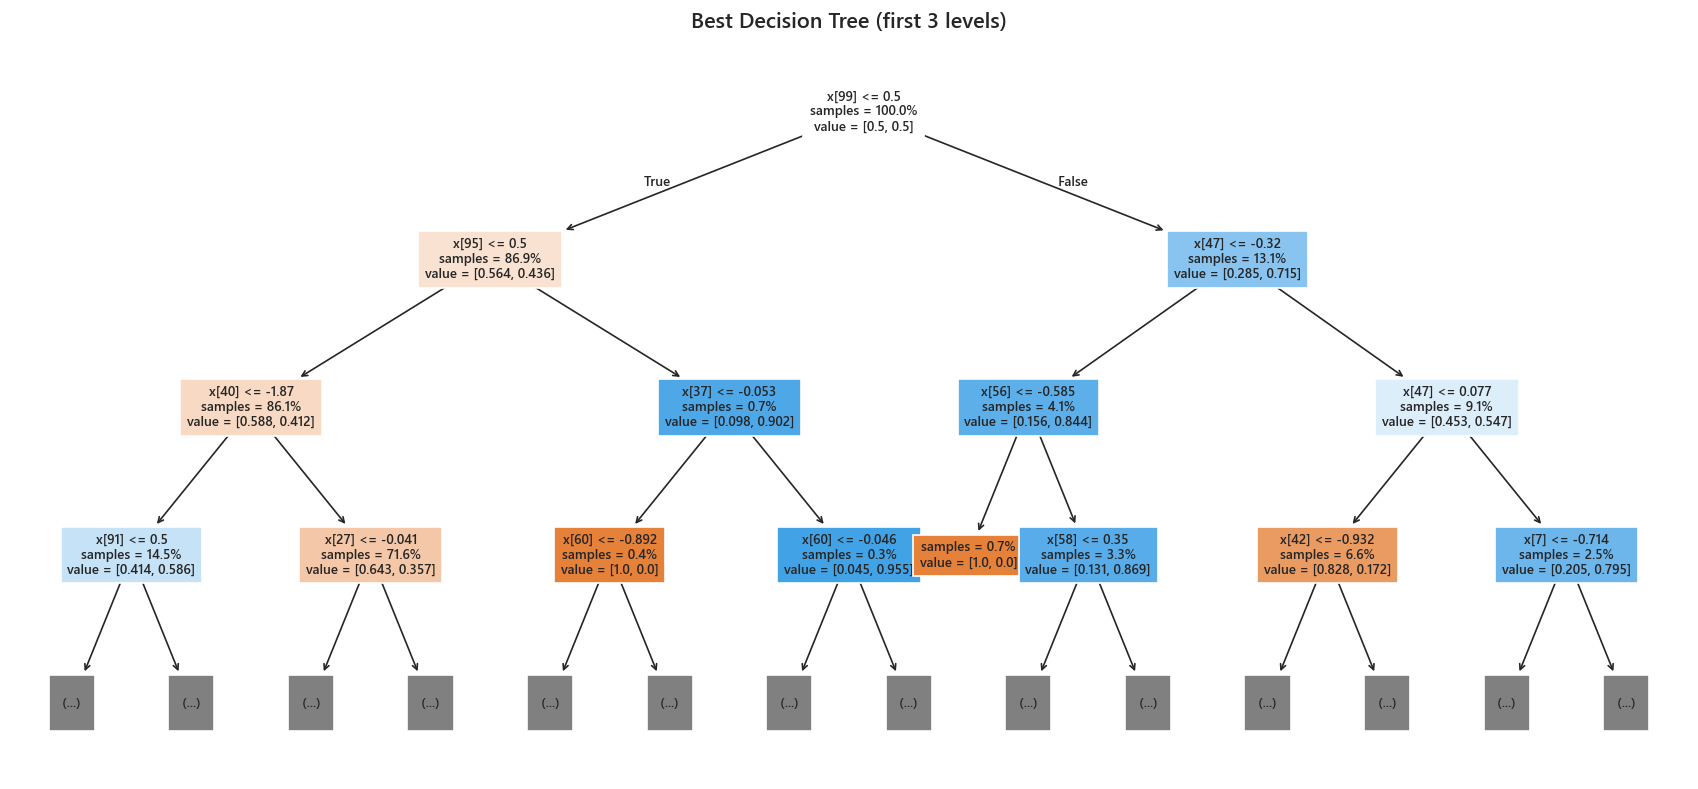

In [60]:
# 2.3 Decision Tree with GridSearchCV
dt_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
])

dt_param_grid = {
    "model__max_depth": [3, 5, 7, 10],
    "model__min_samples_leaf": [5, 10, 20, 50],
}

dt_grid = GridSearchCV(
    estimator=dt_pipe,
    param_grid=dt_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=0
)

t0 = time.time()
dt_grid.fit(X_train, y_train)
dt_train_time = time.time() - t0

best_dt = dt_grid.best_estimator_
best_params_log["Decision Tree"] = dt_grid.best_params_
print("Best Decision Tree params:", dt_grid.best_params_)
print(f"Best CV F1: {dt_grid.best_score_:.4f}")

y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]
metrics_dt = classification_metrics(y_test, y_pred_dt, y_prob_dt)
show_metrics("Decision Tree", metrics_dt)
model_results.append({"model": "Decision Tree", **metrics_dt, "train_seconds": dt_train_time})

# Visualize first levels of the best tree
plt.figure(figsize=(18, 8), dpi=120)
plot_tree(
    best_dt.named_steps["model"],
    max_depth=3,
    filled=True,
    impurity=False,
    proportion=True,
    fontsize=8
)
plt.title("Best Decision Tree (first 3 levels)")
plt.show()

### 2.4 Random Forest
5-fold `GridSearchCV` over `n_estimators` and `max_depth` with F1 scoring, followed by test metrics and ROC curve.

Best Random Forest params: {'model__max_depth': 3, 'model__n_estimators': 200}
Best CV F1: 0.0022
Random Forest test metrics
  accuracy: 0.9607
  precision: 0.0011
  recall: 0.0645
  f1: 0.0023
  roc_auc: 0.5806
  pr_auc: 0.0011


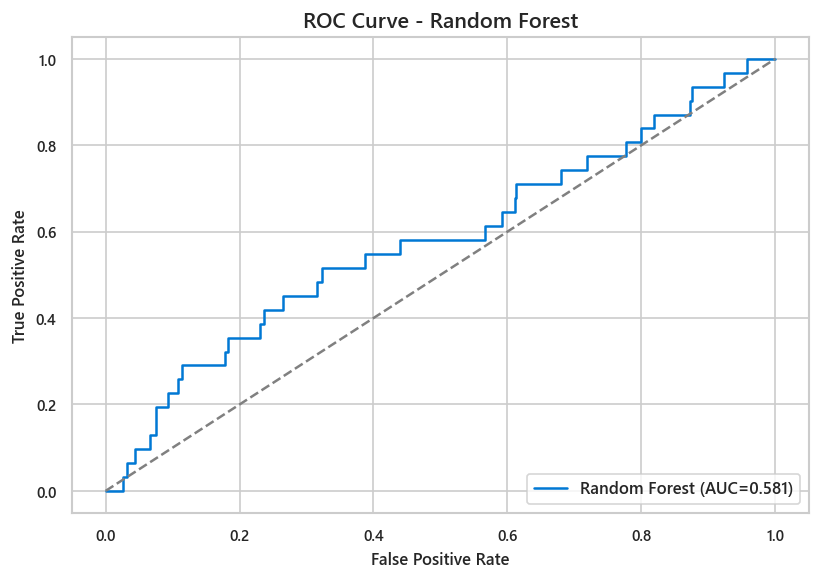

In [61]:
# 2.4 Random Forest with GridSearchCV
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42, class_weight="balanced_subsample", n_jobs=-1))
])

rf_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [3, 5, 8],
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=0
)

t0 = time.time()
rf_grid.fit(X_train, y_train)
rf_train_time = time.time() - t0

best_rf = rf_grid.best_estimator_
best_params_log["Random Forest"] = rf_grid.best_params_
print("Best Random Forest params:", rf_grid.best_params_)
print(f"Best CV F1: {rf_grid.best_score_:.4f}")

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
metrics_rf = classification_metrics(y_test, y_pred_rf, y_prob_rf)
show_metrics("Random Forest", metrics_rf)
model_results.append({"model": "Random Forest", **metrics_rf, "train_seconds": rf_train_time})

# ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(7, 5), dpi=120)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={metrics_rf['roc_auc']:.3f})", color="#0078D4")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 2.5 Boosted Trees — XGBoost
Uses `GridSearchCV` over three hyperparameters (`n_estimators`, `max_depth`, `learning_rate`).
If XGBoost is unavailable in the environment, this cell reports that status and skips model training.

Best XGBoost params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV PR-AUC: 0.0015
XGBoost F1-opt threshold (validation): 0.6199 | val F1=0.0069
XGBoost Recall-first threshold (validation): 0.3342 | val recall=1.0000, val precision=0.0008, target_met=True
XGBoost (F1-opt) test metrics
  accuracy: 0.9914
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  roc_auc: 0.5379
  pr_auc: 0.0008
XGBoost (Recall-first) test metrics
  accuracy: 0.0518
  precision: 0.0007
  recall: 0.9355
  f1: 0.0014
  roc_auc: 0.5379
  pr_auc: 0.0008


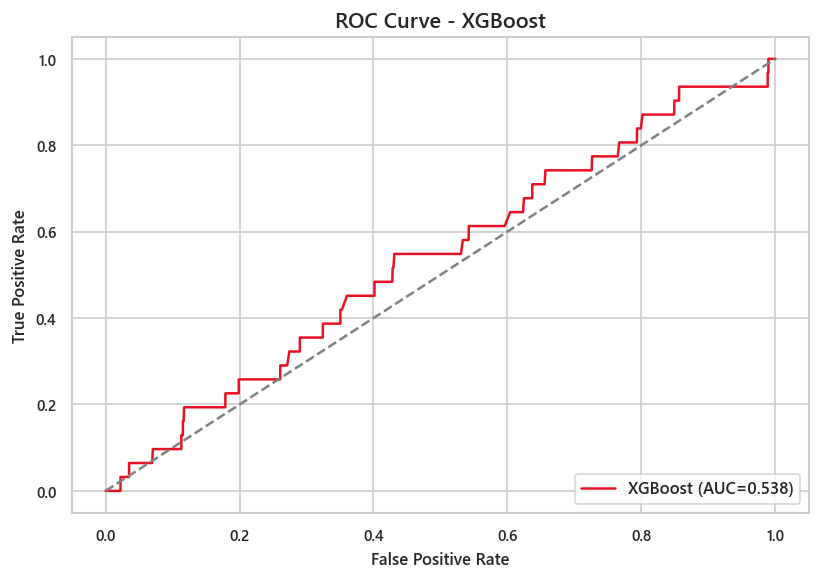

In [62]:
# 2.5 XGBoost with PR-AUC tuning + validation-based operating points
if HAS_XGBOOST:
    pos_count = max(int(y_train.sum()), 1)
    neg_count = max(int(len(y_train) - y_train.sum()), 1)
    scale_pos_weight = neg_count / pos_count

    X_fit, X_val, y_fit, y_val = train_test_split(
        X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
    )

    xgb_pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                tree_method="hist",
                n_jobs=-1,
                scale_pos_weight=scale_pos_weight,
            ),
        ),
    ])

    xgb_param_grid = {
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.01, 0.05, 0.1],
    }

    xgb_grid = GridSearchCV(
        estimator=xgb_pipe,
        param_grid=xgb_param_grid,
        scoring="average_precision",
        cv=cv_strategy,
        n_jobs=-1,
        verbose=0,
    )

    t0 = time.time()
    xgb_grid.fit(X_fit, y_fit)
    xgb_train_time = time.time() - t0

    best_xgb = xgb_grid.best_estimator_
    print("Best XGBoost params:", xgb_grid.best_params_)
    print(f"Best CV PR-AUC: {xgb_grid.best_score_:.4f}")

    # Select thresholds on held-out validation split (not training).
    y_prob_xgb_val = best_xgb.predict_proba(X_val)[:, 1]
    xgb_f1_threshold, xgb_val_f1 = find_best_f1_threshold(y_val, y_prob_xgb_val)
    xgb_rec_threshold, xgb_val_recall, xgb_val_precision, xgb_rec_target_met = find_recall_first_threshold(
        y_val, y_prob_xgb_val, target_recall=0.80
    )
    print(f"XGBoost F1-opt threshold (validation): {xgb_f1_threshold:.4f} | val F1={xgb_val_f1:.4f}")
    print(
        f"XGBoost Recall-first threshold (validation): {xgb_rec_threshold:.4f} | "
        f"val recall={xgb_val_recall:.4f}, val precision={xgb_val_precision:.4f}, "
        f"target_met={xgb_rec_target_met}"
    )

    # Refit best pipeline on full training split before final test evaluation.
    best_xgb.fit(X_train, y_train)
    y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

    y_pred_xgb_f1 = (y_prob_xgb >= xgb_f1_threshold).astype(int)
    metrics_xgb_f1 = classification_metrics(y_test, y_pred_xgb_f1, y_prob_xgb)
    show_metrics("XGBoost (F1-opt)", metrics_xgb_f1)
    model_results.append({
        "model": "XGBoost",
        "operating_point": "F1-opt",
        **metrics_xgb_f1,
        "train_seconds": xgb_train_time,
        "threshold": xgb_f1_threshold
    })

    y_pred_xgb_rec = (y_prob_xgb >= xgb_rec_threshold).astype(int)
    metrics_xgb_rec = classification_metrics(y_test, y_pred_xgb_rec, y_prob_xgb)
    show_metrics("XGBoost (Recall-first)", metrics_xgb_rec)
    model_results.append({
        "model": "XGBoost",
        "operating_point": "Recall-first",
        **metrics_xgb_rec,
        "train_seconds": xgb_train_time,
        "threshold": xgb_rec_threshold
    })

    best_params_log["XGBoost"] = {
        **xgb_grid.best_params_,
        "cv_scoring": "average_precision",
        "f1_opt_threshold": xgb_f1_threshold,
        "recall_first_threshold": xgb_rec_threshold,
        "recall_first_target": 0.80,
    }

    fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
    plt.figure(figsize=(7, 5), dpi=120)
    plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={metrics_xgb_f1['roc_auc']:.3f})", color="#E81123")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - XGBoost")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost is not installed in this environment. Install with: pip install xgboost")
    model_results.append({
        "model": "XGBoost (not run)",
        "operating_point": "N/A",
        "accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan, "roc_auc": np.nan, "pr_auc": np.nan,
        "train_seconds": np.nan, "threshold": np.nan
    })

### 2.6 Neural Network — MLP
Keras/TensorFlow MLP with two hidden layers (128, 128), ReLU activations, sigmoid output, Adam optimizer, and binary cross-entropy loss.
If TensorFlow is unavailable, the cell reports the missing dependency.

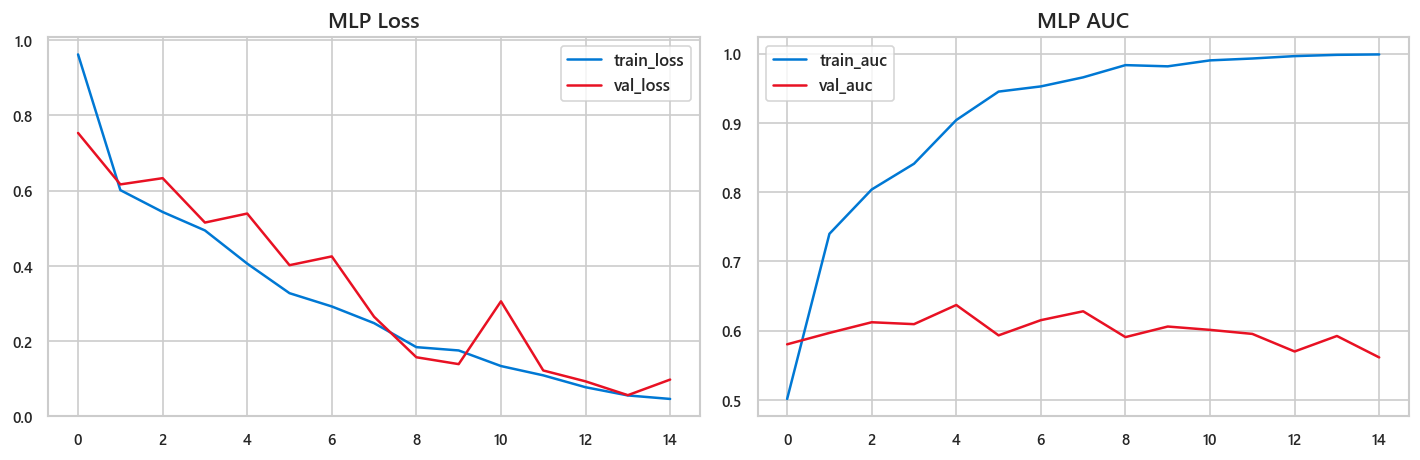

MLP F1-opt threshold (validation): 0.8203 | val F1=0.0134
MLP Recall-first threshold (validation): 0.0008 | val recall=0.8000, val precision=0.0011, target_met=True
MLP (Keras) - F1-opt test metrics
  accuracy: 0.9873
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  roc_auc: 0.5493
  pr_auc: 0.0009
MLP (Keras) - Recall-first test metrics
  accuracy: 0.4732
  precision: 0.0008
  recall: 0.6129
  f1: 0.0016
  roc_auc: 0.5493
  pr_auc: 0.0009


In [63]:
# 2.6 MLP (Keras/TensorFlow) with validation-based operating points
if HAS_TF:
    ohe_kwargs = {"handle_unknown": "ignore"}
    if "sparse_output" in OneHotEncoder.__init__.__code__.co_varnames:
        ohe_kwargs["sparse_output"] = False
    else:
        ohe_kwargs["sparse"] = False

    X_fit, X_val, y_fit, y_val = train_test_split(
        X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
    )

    nn_preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols),
            ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(**ohe_kwargs))]), categorical_cols),
        ]
    )

    X_fit_nn = nn_preprocessor.fit_transform(X_fit)
    X_val_nn = nn_preprocessor.transform(X_val)
    X_test_nn = nn_preprocessor.transform(X_test)

    classes = np.array([0, 1])
    cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_fit.values)
    class_weight = {0: float(cw[0]), 1: float(cw[1])}

    tf.random.set_seed(42)
    np.random.seed(42)

    mlp = keras.Sequential([
        keras.layers.Input(shape=(X_fit_nn.shape[1],)),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ])

    mlp.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.BinaryAccuracy(name="accuracy"), keras.metrics.AUC(name="auc")],
    )

    t0 = time.time()
    history = mlp.fit(
        X_fit_nn, y_fit.values,
        validation_data=(X_val_nn, y_val.values),
        epochs=15,
        batch_size=256,
        class_weight=class_weight,
        verbose=0,
    )
    mlp_train_time = time.time() - t0

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=120)
    axes[0].plot(history.history["loss"], label="train_loss")
    axes[0].plot(history.history["val_loss"], label="val_loss")
    axes[0].set_title("MLP Loss")
    axes[0].legend()
    axes[1].plot(history.history["auc"], label="train_auc")
    axes[1].plot(history.history["val_auc"], label="val_auc")
    axes[1].set_title("MLP AUC")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    y_prob_mlp_val = mlp.predict(X_val_nn, verbose=0).reshape(-1)
    mlp_f1_threshold, mlp_val_f1 = find_best_f1_threshold(y_val.values, y_prob_mlp_val)
    mlp_rec_threshold, mlp_val_recall, mlp_val_precision, mlp_rec_target_met = find_recall_first_threshold(
        y_val.values, y_prob_mlp_val, target_recall=0.80
    )
    print(f"MLP F1-opt threshold (validation): {mlp_f1_threshold:.4f} | val F1={mlp_val_f1:.4f}")
    print(
        f"MLP Recall-first threshold (validation): {mlp_rec_threshold:.4f} | "
        f"val recall={mlp_val_recall:.4f}, val precision={mlp_val_precision:.4f}, "
        f"target_met={mlp_rec_target_met}"
    )

    y_prob_mlp = mlp.predict(X_test_nn, verbose=0).reshape(-1)

    y_pred_mlp_f1 = (y_prob_mlp >= mlp_f1_threshold).astype(int)
    metrics_mlp_f1 = classification_metrics(y_test, y_pred_mlp_f1, y_prob_mlp)
    show_metrics("MLP (Keras) - F1-opt", metrics_mlp_f1)
    model_results.append({
        "model": "MLP (Keras)",
        "operating_point": "F1-opt",
        **metrics_mlp_f1,
        "train_seconds": mlp_train_time,
        "threshold": mlp_f1_threshold
    })

    y_pred_mlp_rec = (y_prob_mlp >= mlp_rec_threshold).astype(int)
    metrics_mlp_rec = classification_metrics(y_test, y_pred_mlp_rec, y_prob_mlp)
    show_metrics("MLP (Keras) - Recall-first", metrics_mlp_rec)
    model_results.append({
        "model": "MLP (Keras)",
        "operating_point": "Recall-first",
        **metrics_mlp_rec,
        "train_seconds": mlp_train_time,
        "threshold": mlp_rec_threshold
    })

    best_params_log["MLP (Keras)"] = {
        "layers": [128, 128],
        "epochs": 15,
        "batch_size": 256,
        "optimizer": "Adam",
        "validation_thresholding": True,
        "f1_opt_threshold": mlp_f1_threshold,
        "recall_first_threshold": mlp_rec_threshold,
        "recall_first_target": 0.80,
    }
else:
    print("TensorFlow is not installed in this environment. Install with: pip install tensorflow")
    model_results.append({
        "model": "MLP (not run)",
        "operating_point": "N/A",
        "accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan, "roc_auc": np.nan, "pr_auc": np.nan,
        "train_seconds": np.nan, "threshold": np.nan
    })

[1/18] layers=(64, 64), lr=0.001, dropout=0.0 -> val_pr_auc=0.0144, val_auc=0.6019, val_best_f1=0.1000
[2/18] layers=(64, 64), lr=0.001, dropout=0.2 -> val_pr_auc=0.0039, val_auc=0.5822, val_best_f1=0.0465
[3/18] layers=(64, 64), lr=0.001, dropout=0.4 -> val_pr_auc=0.0010, val_auc=0.5634, val_best_f1=0.0030
[4/18] layers=(64, 64), lr=0.0005, dropout=0.0 -> val_pr_auc=0.0014, val_auc=0.6413, val_best_f1=0.0078
[5/18] layers=(64, 64), lr=0.0005, dropout=0.2 -> val_pr_auc=0.0017, val_auc=0.5426, val_best_f1=0.0196
[6/18] layers=(64, 64), lr=0.0005, dropout=0.4 -> val_pr_auc=0.0016, val_auc=0.6135, val_best_f1=0.0164
[7/18] layers=(128, 128), lr=0.001, dropout=0.0 -> val_pr_auc=0.0020, val_auc=0.6329, val_best_f1=0.0179
[8/18] layers=(128, 128), lr=0.001, dropout=0.2 -> val_pr_auc=0.0017, val_auc=0.5759, val_best_f1=0.0108
[9/18] layers=(128, 128), lr=0.001, dropout=0.4 -> val_pr_auc=0.0044, val_auc=0.5901, val_best_f1=0.0571
[10/18] layers=(128, 128), lr=0.0005, dropout=0.0 -> val_pr_auc=

,hidden_layers,learning_rate,dropout_rate,val_auc,val_pr_auc,val_best_f1,val_best_threshold,best_epoch
0,"(64, 64)",0.0010,0.0,0.601916,0.014359,0.100000,0.942726,3
1,"(128, 128)",0.0010,0.4,0.590117,0.004357,0.057143,0.935381,5
2,"(64, 64)",0.0010,0.2,0.582181,0.003895,0.046512,0.900055,4
3,"(128, 64)",0.0005,0.2,0.632544,0.003252,0.040000,0.881053,5
4,"(128, 128)",0.0005,0.0,0.645153,0.002799,0.036364,0.865310,1
5,"(128, 128)",0.0010,0.0,0.632852,0.001950,0.017857,0.827033,2
6,"(128, 128)",0.0010,0.2,0.575910,0.001747,0.010791,0.836976,5
7,"(128, 64)",0.0010,0.2,0.631049,0.001668,0.007673,0.775231,4
8,"(64, 64)",0.0005,0.2,0.542556,0.001662,0.019608,0.860586,4
9,"(64, 64)",0.0005,0.4,0.613518,0.001628,0.016393,0.811453,7


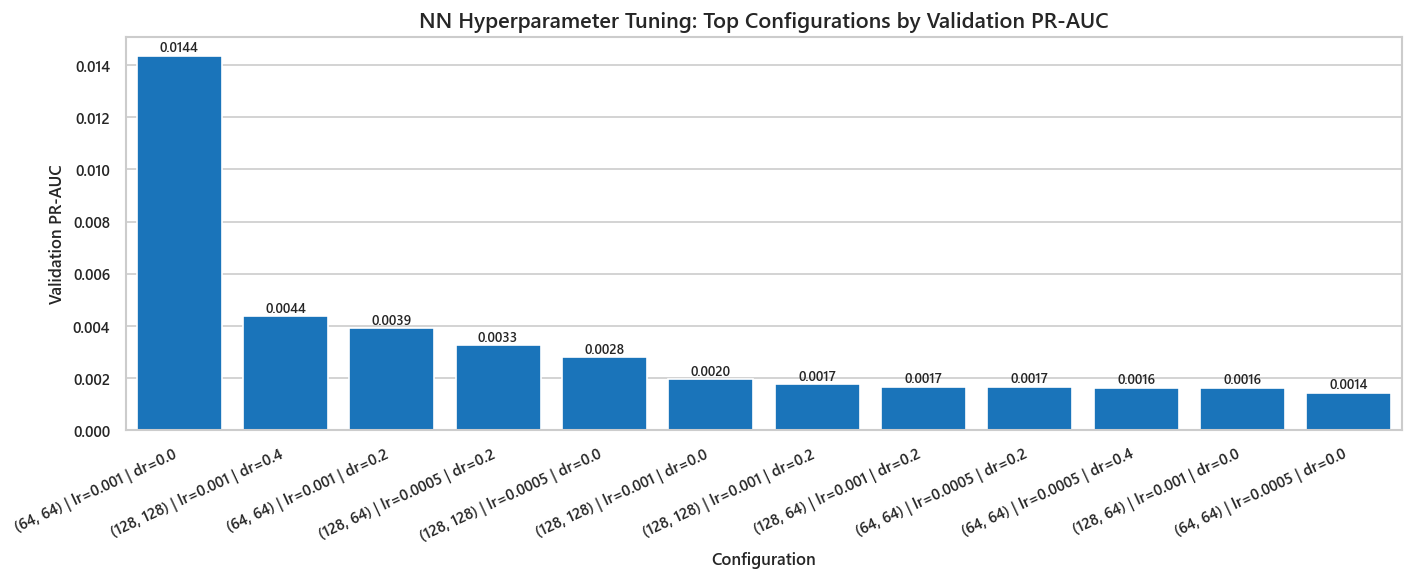

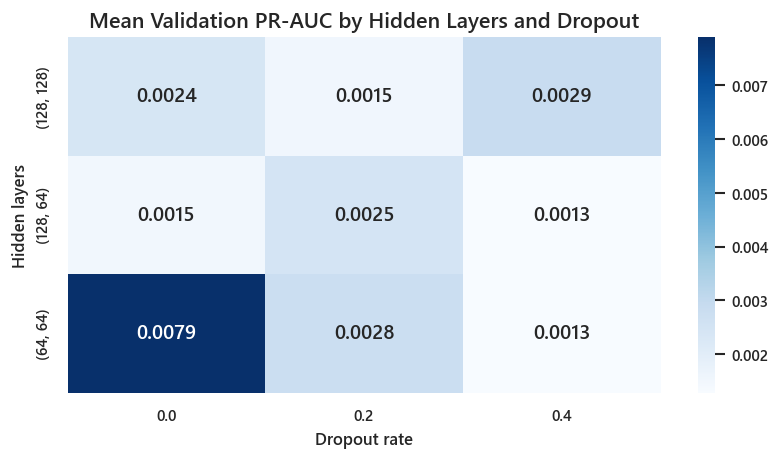

Best NN tuning configuration (validation):
{'hidden_layers': '(64, 64)', 'learning_rate': 0.001, 'dropout_rate': 0.0, 'val_auc': 0.601915654038599, 'val_pr_auc': 0.014358715406574839, 'val_best_f1': 0.1, 'val_best_threshold': 0.9427264332771301, 'best_epoch': 3}


In [75]:
# 2.6b Neural Network hyperparameter tuning (hidden layers, learning rate, dropout)
if HAS_TF:
    # Compact search space to keep runtime manageable.
    nn_hidden_grid = [(64, 64), (128, 128), (128, 64)]
    nn_lr_grid = [1e-3, 5e-4]
    nn_dropout_grid = [0.0, 0.2, 0.4]

    nn_tuning_rows = []

    def build_mlp(input_dim, hidden_layers=(128, 128), dropout_rate=0.0, lr=1e-3):
        model = keras.Sequential()
        model.add(keras.layers.Input(shape=(input_dim,)))
        for units in hidden_layers:
            model.add(keras.layers.Dense(units, activation="relu"))
            if dropout_rate > 0:
                model.add(keras.layers.Dropout(dropout_rate))
        model.add(keras.layers.Dense(1, activation="sigmoid"))
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            loss="binary_crossentropy",
            metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="accuracy")],
        )
        return model

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=2,
        restore_best_weights=True,
        verbose=0,
    )

    combo_idx = 0
    total_combos = len(nn_hidden_grid) * len(nn_lr_grid) * len(nn_dropout_grid)
    for hidden_layers in nn_hidden_grid:
        for lr in nn_lr_grid:
            for dropout_rate in nn_dropout_grid:
                combo_idx += 1
                tf.random.set_seed(42)
                np.random.seed(42)

                tune_model = build_mlp(
                    input_dim=X_fit_nn.shape[1],
                    hidden_layers=hidden_layers,
                    dropout_rate=dropout_rate,
                    lr=lr,
                )

                history_tune = tune_model.fit(
                    X_fit_nn, y_fit.values,
                    validation_data=(X_val_nn, y_val.values),
                    epochs=12,
                    batch_size=256,
                    class_weight=class_weight,
                    callbacks=[early_stop],
                    verbose=0,
                )

                val_prob = tune_model.predict(X_val_nn, verbose=0).reshape(-1)
                val_auc = float(roc_auc_score(y_val.values, val_prob))
                val_pr_auc = float(average_precision_score(y_val.values, val_prob))
                val_thr, val_best_f1 = find_best_f1_threshold(y_val.values, val_prob)
                best_epoch = int(np.argmax(history_tune.history.get("val_auc", [0])) + 1)

                nn_tuning_rows.append({
                    "hidden_layers": str(hidden_layers),
                    "learning_rate": lr,
                    "dropout_rate": dropout_rate,
                    "val_auc": val_auc,
                    "val_pr_auc": val_pr_auc,
                    "val_best_f1": float(val_best_f1),
                    "val_best_threshold": float(val_thr),
                    "best_epoch": best_epoch,
                })

                print(
                    f"[{combo_idx}/{total_combos}] layers={hidden_layers}, lr={lr}, dropout={dropout_rate} -> "
                    f"val_pr_auc={val_pr_auc:.4f}, val_auc={val_auc:.4f}, val_best_f1={val_best_f1:.4f}"
                )

    nn_tuning_results = pd.DataFrame(nn_tuning_rows).sort_values(
        ["val_pr_auc", "val_best_f1", "val_auc"],
        ascending=False,
    ).reset_index(drop=True)

    print("Top neural network hyperparameter settings (validation):")
    display(nn_tuning_results.head(10))

    # Visualization 1: ranked bar chart by validation PR-AUC.
    plot_tune = nn_tuning_results.head(12).copy()
    plot_tune["label"] = (
        plot_tune["hidden_layers"]
        + " | lr=" + plot_tune["learning_rate"].astype(str)
        + " | dr=" + plot_tune["dropout_rate"].astype(str)
    )

    plt.figure(figsize=(12, 5), dpi=120)
    ax = sns.barplot(data=plot_tune, x="label", y="val_pr_auc", color="#0078D4")
    plt.title("NN Hyperparameter Tuning: Top Configurations by Validation PR-AUC")
    plt.xlabel("Configuration")
    plt.ylabel("Validation PR-AUC")
    plt.xticks(rotation=25, ha="right")
    for i, row in plot_tune.reset_index(drop=True).iterrows():
        ax.text(i, row["val_pr_auc"] + 0.00005, f"{row['val_pr_auc']:.4f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

    # Visualization 2: heatmap of average PR-AUC by hidden layers and dropout.
    heat = (
        nn_tuning_results.groupby(["hidden_layers", "dropout_rate"], as_index=False)["val_pr_auc"]
        .mean()
        .pivot(index="hidden_layers", columns="dropout_rate", values="val_pr_auc")
    )
    plt.figure(figsize=(7, 4), dpi=120)
    sns.heatmap(heat, annot=True, fmt=".4f", cmap="Blues")
    plt.title("Mean Validation PR-AUC by Hidden Layers and Dropout")
    plt.xlabel("Dropout rate")
    plt.ylabel("Hidden layers")
    plt.tight_layout()
    plt.show()

    best_nn_cfg = nn_tuning_results.iloc[0].to_dict()
    print("Best NN tuning configuration (validation):")
    print(best_nn_cfg)

    best_params_log["MLP (Keras) - tuned"] = {
        "hidden_layers": best_nn_cfg["hidden_layers"],
        "learning_rate": float(best_nn_cfg["learning_rate"]),
        "dropout_rate": float(best_nn_cfg["dropout_rate"]),
        "val_pr_auc": float(best_nn_cfg["val_pr_auc"]),
        "val_auc": float(best_nn_cfg["val_auc"]),
        "val_best_f1": float(best_nn_cfg["val_best_f1"]),
        "val_best_threshold": float(best_nn_cfg["val_best_threshold"]),
        "best_epoch": int(best_nn_cfg["best_epoch"]),
    }
else:
    print("TensorFlow is not installed in this environment. Install with: pip install tensorflow")

### 2.7 Model Comparison Summary
This section compiles all test metrics, compares F1 scores, and provides a short interpretation of trade-offs.

Model comparison (test set):


,model,operating_point,accuracy,precision,recall,f1,roc_auc,pr_auc,train_seconds,threshold
0,Logistic Regression,Default-0.5,0.7698,0.0012,0.3871,0.0023,0.6312,0.0018,13.2,N/A
1,Random Forest,Default-0.5,0.9607,0.0011,0.0645,0.0023,0.5806,0.0011,166.6,N/A
2,MLP (Keras),Recall-first,0.4732,0.0008,0.6129,0.0016,0.5493,0.0009,21.6,0.0008
3,XGBoost,Recall-first,0.0518,0.0007,0.9355,0.0014,0.5379,0.0008,111.5,0.3342
4,Decision Tree,Default-0.5,0.8994,0.0004,0.0645,0.0009,0.4772,0.0007,115.4,N/A
5,XGBoost,F1-opt,0.9914,0.0000,0.0000,0.0000,0.5379,0.0008,111.5,0.6199
6,MLP (Keras),F1-opt,0.9873,0.0000,0.0000,0.0000,0.5493,0.0009,21.6,0.8203


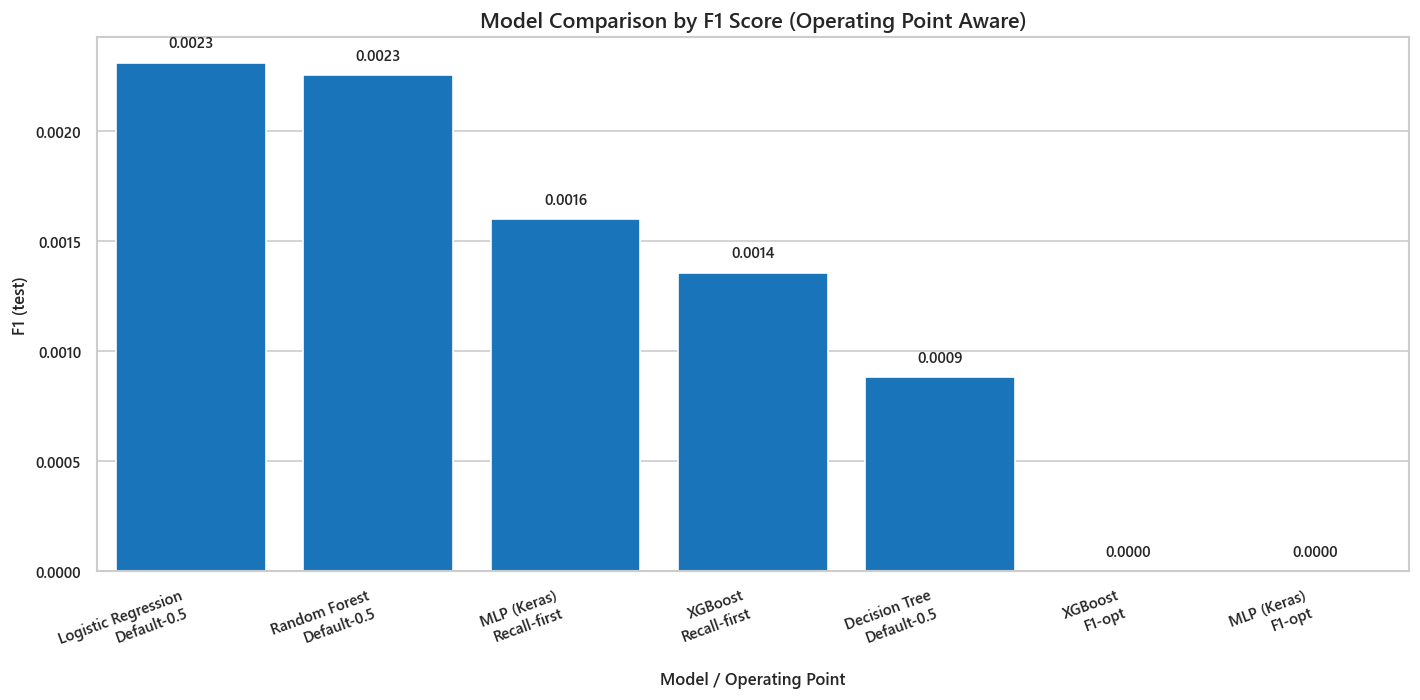

Brief comparison:
Best row by F1 is Logistic Regression [Default-0.5] (F1=0.0023, Recall=0.3871, PR-AUC=0.0018).
For rare-event applications, compare Recall-first rows in addition to F1-opt rows before selecting a deployment threshold.
Saved best hyperparameters:


,model,best_params
0,Logistic Regression,"{'class_weight': 'balanced', 'max_iter': 1000}"
1,Decision Tree,"{'model__max_depth': 7, 'model__min_samples_le..."
2,Random Forest,"{'model__max_depth': 3, 'model__n_estimators':..."
3,XGBoost,"{'model__learning_rate': 0.01, 'model__max_dep..."
4,MLP (Keras),"{'layers': [128, 128], 'epochs': 15, 'batch_si..."


In [64]:
# 2.7 Summary table and comparison chart
results_df = pd.DataFrame(model_results).copy()

if "operating_point" not in results_df.columns:
    results_df["operating_point"] = "Default-0.5"
else:
    results_df["operating_point"] = results_df["operating_point"].fillna("Default-0.5")

if "threshold" not in results_df.columns:
    results_df["threshold"] = np.nan

metric_order = [
    "model", "operating_point", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "train_seconds", "threshold"
 ]
results_df = results_df[[c for c in metric_order if c in results_df.columns]]
results_df = results_df.sort_values(["f1", "recall"], ascending=False, na_position="last").reset_index(drop=True)

print("Model comparison (test set):")
display(results_df.style.format({
    "accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
    "roc_auc": "{:.4f}",
    "pr_auc": "{:.4f}",
    "train_seconds": "{:.1f}",
    "threshold": "{:.4f}"
}, na_rep="N/A"))

plot_df = results_df.dropna(subset=["f1"]).copy()
plot_df["label"] = plot_df["model"] + "\n" + plot_df["operating_point"]

plt.figure(figsize=(12, 6), dpi=120)
ax = sns.barplot(data=plot_df, x="label", y="f1", color="#0078D4")
plt.title("Model Comparison by F1 Score (Operating Point Aware)")
plt.xlabel("Model / Operating Point")
plt.ylabel("F1 (test)")
plt.xticks(rotation=20, ha="right")

for i, row in plot_df.reset_index(drop=True).iterrows():
    ax.text(i, row["f1"] + 0.00005, f"{row['f1']:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

if len(plot_df) > 0:
    best_row = plot_df.iloc[0]
    print("Brief comparison:")
    print(
        f"Best row by F1 is {best_row['model']} [{best_row['operating_point']}] "
        f"(F1={best_row['f1']:.4f}, Recall={best_row['recall']:.4f}, PR-AUC={best_row['pr_auc']:.4f})."
    )
    print("For rare-event applications, compare Recall-first rows in addition to F1-opt rows before selecting a deployment threshold.")

print("Saved best hyperparameters:")
display(pd.DataFrame([{"model": k, "best_params": str(v)} for k, v in best_params_log.items()]))

In [65]:
# Streamlit integration artifact (Part 2 outputs)
streamlit_part2_artifacts = {
    "results_table": results_df.copy(),
    "best_params": best_params_log.copy(),
}

print("Streamlit-ready objects created: streamlit_part2_artifacts['results_table'], streamlit_part2_artifacts['best_params']")
print("Example Streamlit usage:")
print("""
import streamlit as st
st.subheader('Part 2 Model Comparison')
st.dataframe(streamlit_part2_artifacts['results_table'])
best = streamlit_part2_artifacts['results_table'].dropna(subset=['f1']).iloc[0]
st.write(f"Best model: {best['model']} (F1={best['f1']:.4f})")
""")

Streamlit-ready objects created: streamlit_part2_artifacts['results_table'], streamlit_part2_artifacts['best_params']
Example Streamlit usage:

import streamlit as st
st.subheader('Part 2 Model Comparison')
st.dataframe(streamlit_part2_artifacts['results_table'])
best = streamlit_part2_artifacts['results_table'].dropna(subset=['f1']).iloc[0]
st.write(f"Best model: {best['model']} (F1={best['f1']:.4f})")



## Part 3: Explainability
### 3.1 SHAP Analysis
This section uses the best-performing tree-based model available in the current run (`Random Forest` or `XGBoost`) and provides:
1. Summary plot (beeswarm)
2. Bar plot of mean absolute SHAP values
3. Waterfall plot for one selected high-risk prediction

In [66]:
# 3.1 SHAP setup: choose best tree model and compute SHAP values on a manageable sample
from scipy import sparse

TREE_MODELS = ["Random Forest", "XGBoost"]

selected_tree_name = None
selected_tree_pipeline = None

if "results_df" in globals() and not results_df.empty:
    tree_rows = results_df[results_df["model"].isin(TREE_MODELS)].copy()
    if not tree_rows.empty:
        model_rank = (
            tree_rows.groupby("model", as_index=False)
            .agg(best_pr_auc=("pr_auc", "max"), best_f1=("f1", "max"), best_auc=("roc_auc", "max"))
            .sort_values(["best_pr_auc", "best_f1", "best_auc"], ascending=False)
        )
        selected_tree_name = model_rank.iloc[0]["model"]

if selected_tree_name == "Random Forest" and "best_rf" in globals():
    selected_tree_pipeline = best_rf
elif selected_tree_name == "XGBoost" and "best_xgb" in globals():
    selected_tree_pipeline = best_xgb
elif "best_xgb" in globals():
    selected_tree_name = "XGBoost"
    selected_tree_pipeline = best_xgb
elif "best_rf" in globals():
    selected_tree_name = "Random Forest"
    selected_tree_pipeline = best_rf
else:
    raise RuntimeError("No fitted tree model found. Run Part 2 tree-model cells first.")

print(f"Selected tree model for SHAP: {selected_tree_name}")

# Use a subset for SHAP runtime control.
SHAP_SAMPLE_N = min(400, len(X_test))
X_shap_raw = X_test.sample(SHAP_SAMPLE_N, random_state=42).copy()

shap_preprocessor = selected_tree_pipeline.named_steps["preprocess"]
shap_model = selected_tree_pipeline.named_steps["model"]
X_shap_trans = shap_preprocessor.transform(X_shap_raw)
feature_names = shap_preprocessor.get_feature_names_out()

def pretty_transformed_name(tname, categorical_source_cols):
    if "__" in tname:
        prefix, rest = tname.split("__", 1)
    else:
        prefix, rest = "", tname

    if prefix == "num":
        return friendly_name(rest) if "friendly_name" in globals() else rest

    if prefix == "cat":
        matches = [c for c in categorical_source_cols if rest == c or rest.startswith(c + "_")]
        if matches:
            base_col = max(matches, key=len)
            base_label = friendly_name(base_col) if "friendly_name" in globals() else base_col
            if rest == base_col:
                return base_label
            level = rest[len(base_col) + 1 :]
            return f"{base_label} = {level}"
        return rest

    return friendly_name(rest) if "friendly_name" in globals() else rest

cat_cols_for_labels = categorical_cols if "categorical_cols" in globals() else []
feature_display_names = [pretty_transformed_name(n, cat_cols_for_labels) for n in feature_names]

explainer = shap.TreeExplainer(shap_model)
shap_values_raw = explainer.shap_values(X_shap_trans)

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1] if len(shap_values_raw) > 1 else shap_values_raw[0]
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    shap_values = shap_values_raw[:, :, 1]
else:
    shap_values = shap_values_raw

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = float(np.ravel(expected_value)[-1])
else:
    expected_value = float(expected_value)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_n = min(20, len(mean_abs_shap))
top_idx = np.argsort(mean_abs_shap)[-top_n:][::-1]
top_feature_names = np.array(feature_names)[top_idx]
top_feature_display_names = [pretty_transformed_name(n, cat_cols_for_labels) for n in top_feature_names]

# Prepare compact matrix (top features only) for summary plotting.
X_shap_top = X_shap_trans[:, top_idx]
if sparse.issparse(X_shap_top):
    X_shap_top = X_shap_top.toarray()

print(f"SHAP sample rows: {SHAP_SAMPLE_N}")
print(f"Total transformed features: {len(feature_names)}")
print(f"Plotting top features: {len(top_idx)}")

Selected tree model for SHAP: Random Forest
SHAP sample rows: 400
Total transformed features: 102
Plotting top features: 20


1) SHAP Summary Plot (Beeswarm)


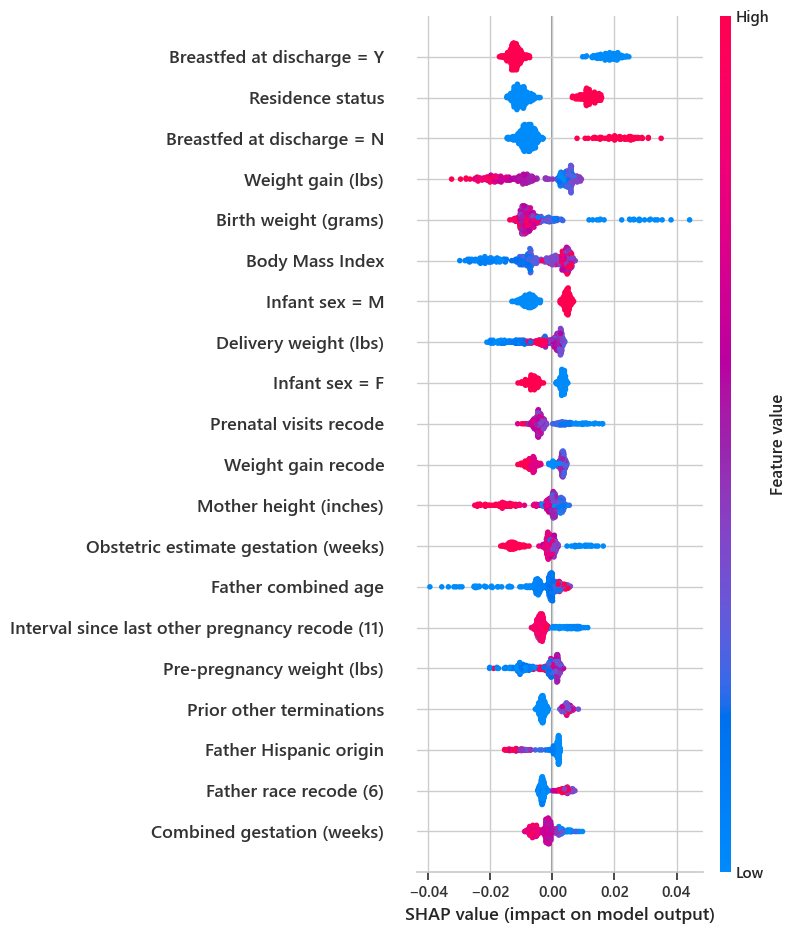

2) SHAP Bar Plot (Mean |SHAP|)


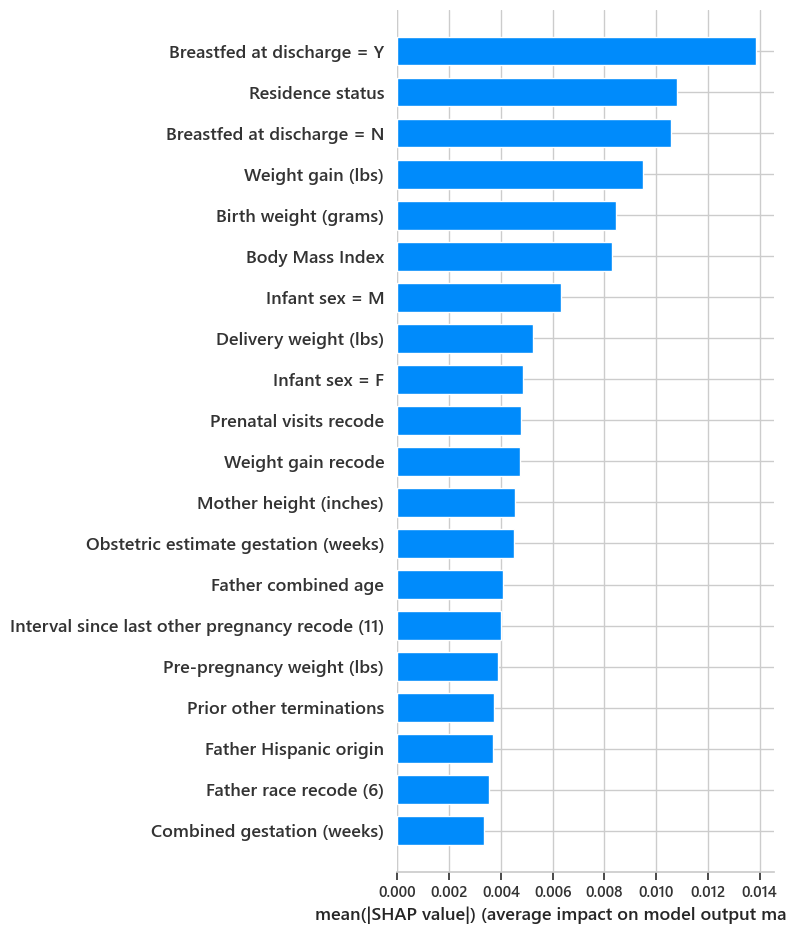

3) SHAP Waterfall Plot (one high-risk prediction)
Selected case index in SHAP sample: 160
Predicted risk for selected case: 0.5856


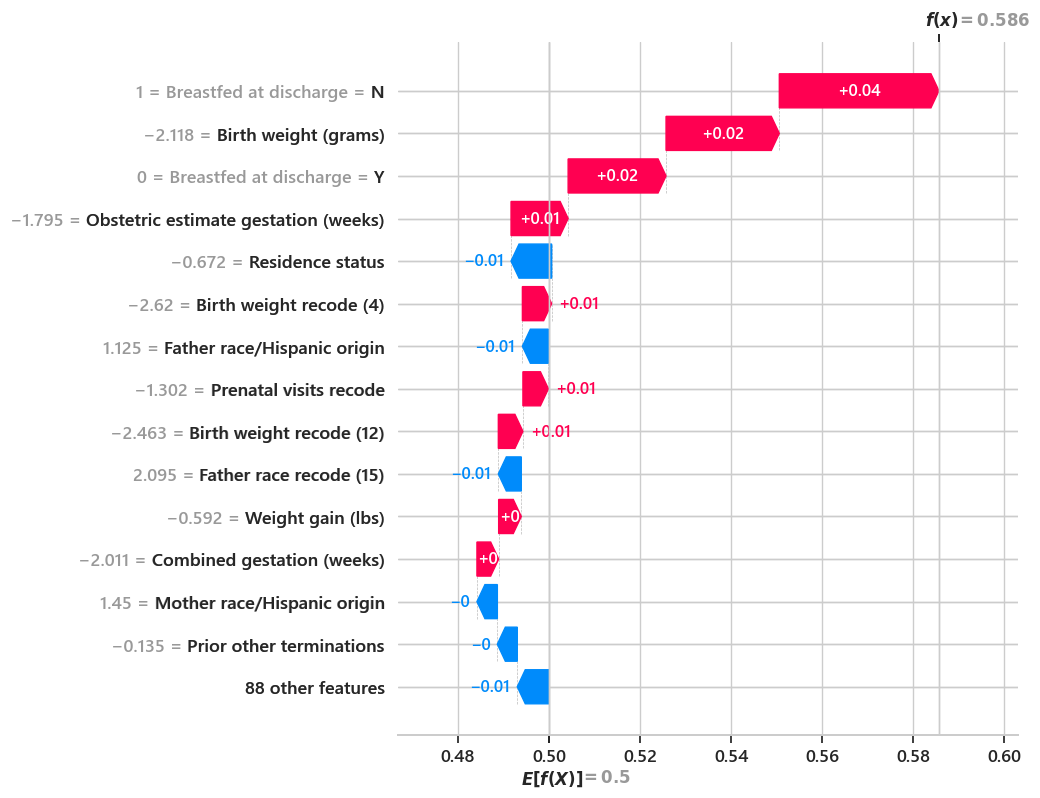

In [67]:
# 3.1 Required SHAP plots: beeswarm, bar, waterfall
print("1) SHAP Summary Plot (Beeswarm)")
shap.summary_plot(
    shap_values[:, top_idx],
    features=X_shap_top,
    feature_names=top_feature_display_names,
    max_display=min(20, len(top_idx)),
    show=True
 )

print("2) SHAP Bar Plot (Mean |SHAP|)")
shap.summary_plot(
    shap_values[:, top_idx],
    features=X_shap_top,
    feature_names=top_feature_display_names,
    plot_type="bar",
    max_display=min(20, len(top_idx)),
    show=True
 )

print("3) SHAP Waterfall Plot (one high-risk prediction)")
sample_pred_prob = selected_tree_pipeline.predict_proba(X_shap_raw)[:, 1]
waterfall_idx = int(np.argmax(sample_pred_prob))

row_trans = X_shap_trans[waterfall_idx]
if sparse.issparse(row_trans):
    row_trans = row_trans.toarray().ravel()
else:
    row_trans = np.asarray(row_trans).ravel()

waterfall_explanation = shap.Explanation(
    values=shap_values[waterfall_idx],
    base_values=expected_value,
    data=row_trans,
    feature_names=feature_display_names
 )

print(f"Selected case index in SHAP sample: {waterfall_idx}")
print(f"Predicted risk for selected case: {sample_pred_prob[waterfall_idx]:.4f}")
shap.plots.waterfall(waterfall_explanation, max_display=15)

In [68]:
# 3.1 Interpretation outputs for rubric questions
top_k = min(10, len(top_idx))
interp_rows = []

for j in range(top_k):
    col_idx = int(top_idx[j])
    fname = feature_names[col_idx]
    shap_col = shap_values[:, col_idx]

    feature_col = X_shap_trans[:, col_idx]
    if sparse.issparse(feature_col):
        feature_col = feature_col.toarray().ravel()
    else:
        feature_col = np.asarray(feature_col).ravel()

    if np.nanstd(feature_col) > 0 and np.nanstd(shap_col) > 0:
        corr = np.corrcoef(feature_col, shap_col)[0, 1]
    else:
        corr = np.nan

    if np.isnan(corr):
        direction = "mixed/flat effect"
    elif corr > 0.05:
        direction = "higher feature values tend to increase predicted risk"
    elif corr < -0.05:
        direction = "higher feature values tend to decrease predicted risk"
    else:
        direction = "weak or mixed direction"

    interp_rows.append({
        "feature": fname,
        "mean_abs_shap": float(np.mean(np.abs(shap_col))),
        "mean_shap": float(np.mean(shap_col)),
        "value_shap_corr": float(corr) if not np.isnan(corr) else np.nan,
        "directional_interpretation": direction
    })

shap_interpretation_df = pd.DataFrame(interp_rows).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
display(shap_interpretation_df)

print("Interpretation:")
print("- Strongest impact features are the top rows above by mean absolute SHAP value.")
print("- Positive SHAP values push predictions toward higher cleft-case risk; negative values push toward lower risk.")
print("- Directional interpretation column summarizes whether higher feature values generally raise or lower risk.")

print("Decision-maker usefulness:")
print("- Prioritize screening resources for profiles where high-impact features align with positive SHAP contribution.")
print("- Use low-risk profiles (negative SHAP patterns) to avoid over-allocation and improve triage efficiency.")
print("- Translate top drivers into targeted prevention and maternal-care interventions (e.g., risk communication, early referral workflows).")

,feature,mean_abs_shap,mean_shap,value_shap_corr,directional_interpretation
0,cat__BFED_Y,0.013860,-0.003399,-0.987986,higher feature values tend to decrease predict...
1,num__RESTATUS,0.010823,-0.002783,0.908557,higher feature values tend to increase predict...
2,cat__BFED_N,0.010557,-0.002827,0.968365,higher feature values tend to increase predict...
3,num__WTGAIN,0.009495,-0.004381,-0.818237,higher feature values tend to decrease predict...
4,num__DBWT,0.008451,-0.005342,-0.742092,higher feature values tend to decrease predict...
5,num__BMI,0.008306,-0.004726,0.525635,higher feature values tend to increase predict...
6,cat__SEX_M,0.006326,-0.001874,0.975135,higher feature values tend to increase predict...
7,num__DWgt_R,0.005256,-0.003236,0.323507,higher feature values tend to increase predict...
8,cat__SEX_F,0.004857,-0.001723,-0.974535,higher feature values tend to decrease predict...
9,num__PREVIS_REC,0.004777,-0.002383,-0.783544,higher feature values tend to decrease predict...


Interpretation:
- Strongest impact features are the top rows above by mean absolute SHAP value.
- Positive SHAP values push predictions toward higher cleft-case risk; negative values push toward lower risk.
- Directional interpretation column summarizes whether higher feature values generally raise or lower risk.
Decision-maker usefulness:
- Prioritize screening resources for profiles where high-impact features align with positive SHAP contribution.
- Use low-risk profiles (negative SHAP patterns) to avoid over-allocation and improve triage efficiency.
- Translate top drivers into targeted prevention and maternal-care interventions (e.g., risk communication, early referral workflows).


### 3.2 Leakage-safe SHAP (Pre-birth Features Only)
This rerun removes likely leakage/post-outcome variables so explainability reflects signals that would be available for real-world early risk screening.

In [69]:
# 3.2 Build leakage-safe model with pre-birth features only
from sklearn.metrics import average_precision_score

target_col_safe = "cleft_case"
if target_col_safe not in nat2024us.columns:
    nat2024us[target_col_safe] = (
        (nat2024us["CA_CLEFT"].astype("string").str.strip() == "Y")
        | (nat2024us["CA_CLPAL"].astype("string").str.strip() == "Y")
    ).astype(int)

# Exclude target-derivation fields and likely post-birth/outcome variables.
post_outcome_cols = {
    "CA_CLEFT", "CA_CLPAL", "DBWT", "BWTR12", "BWTR4",
    "ILIVE", "BFED", "F_BFED", "ITRAN"
}

if "domain_map" in globals() and "infant_outcomes" in domain_map:
    post_outcome_cols = post_outcome_cols.union(set(domain_map["infant_outcomes"]))
post_outcome_cols.discard(target_col_safe)

safe_features = [c for c in nat2024us.columns if c not in post_outcome_cols.union({target_col_safe})]
safe_df = nat2024us[safe_features + [target_col_safe]].copy()
safe_df[target_col_safe] = pd.to_numeric(safe_df[target_col_safe], errors="coerce")
safe_df = safe_df.dropna(subset=[target_col_safe]).copy()
safe_df[target_col_safe] = safe_df[target_col_safe].astype(int)

SAFE_MAX_ROWS = 150000
if len(safe_df) > SAFE_MAX_ROWS:
    by_class_safe = safe_df[target_col_safe].value_counts()
    safe_df = (
        safe_df.groupby(target_col_safe, group_keys=False)
        .apply(lambda d: d.sample(min(len(d), max(1, int(SAFE_MAX_ROWS * len(d) / len(safe_df)))), random_state=42))
        .reset_index(drop=True)
    )

X_safe = safe_df[safe_features].copy()
y_safe = safe_df[target_col_safe].copy()

safe_numeric_cols = []
safe_categorical_cols = []
for col in X_safe.columns:
    ratio_numeric = pd.to_numeric(X_safe[col], errors="coerce").notna().mean()
    if ratio_numeric >= 0.98:
        safe_numeric_cols.append(col)
    else:
        safe_categorical_cols.append(col)

for col in safe_numeric_cols:
    X_safe[col] = pd.to_numeric(X_safe[col], errors="coerce")
for col in safe_categorical_cols:
    X_safe[col] = X_safe[col].astype("string")

X_safe_train, X_safe_test, y_safe_train, y_safe_test = train_test_split(
    X_safe, y_safe, test_size=0.30, random_state=42, stratify=y_safe
)

# Ensure sklearn imputers see missing as np.nan, not pandas NA.
for c in safe_categorical_cols:
    X_safe_train[c] = X_safe_train[c].astype("object").where(X_safe_train[c].notna(), np.nan)
    X_safe_test[c] = X_safe_test[c].astype("object").where(X_safe_test[c].notna(), np.nan)

safe_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), safe_numeric_cols),
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), safe_categorical_cols),
    ]
 )

safe_rf_pipe = Pipeline(steps=[
    ("preprocess", safe_preprocessor),
    ("model", RandomForestClassifier(random_state=42, class_weight="balanced_subsample", n_jobs=-1)),
])

safe_rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 8],
}

safe_rf_grid = GridSearchCV(
    estimator=safe_rf_pipe,
    param_grid=safe_rf_param_grid,
    scoring="average_precision",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=0,
 )

safe_rf_grid.fit(X_safe_train, y_safe_train)
safe_best_rf = safe_rf_grid.best_estimator_
safe_y_prob = safe_best_rf.predict_proba(X_safe_test)[:, 1]
safe_y_pred = (safe_y_prob >= 0.5).astype(int)

safe_metrics = classification_metrics(y_safe_test, safe_y_pred, safe_y_prob)
print("Leakage-safe model: Random Forest")
print("Best params:", safe_rf_grid.best_params_)
print(f"Best CV PR-AUC: {safe_rf_grid.best_score_:.4f}")
show_metrics("Leakage-safe Random Forest", safe_metrics)
print(f"Leakage-safe Test PR-AUC: {average_precision_score(y_safe_test, safe_y_prob):.4f}")
print(f"Leakage-safe feature count: {len(safe_features)}")

C:\Users\mimarqu\AppData\Local\Temp\ipykernel_62492\531412261.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.sample(min(len(d), max(1, int(SAFE_MAX_ROWS * len(d) / len(safe_df)))), random_state=42))


Leakage-safe model: Random Forest
Best params: {'model__max_depth': 3, 'model__n_estimators': 100}
Best CV PR-AUC: 0.0013
Leakage-safe Random Forest test metrics
  accuracy: 0.9468
  precision: 0.0013
  recall: 0.0968
  f1: 0.0025
  roc_auc: 0.5771
  pr_auc: 0.0009
Leakage-safe Test PR-AUC: 0.0009
Leakage-safe feature count: 75


Leakage-safe SHAP Summary Plot (Beeswarm)


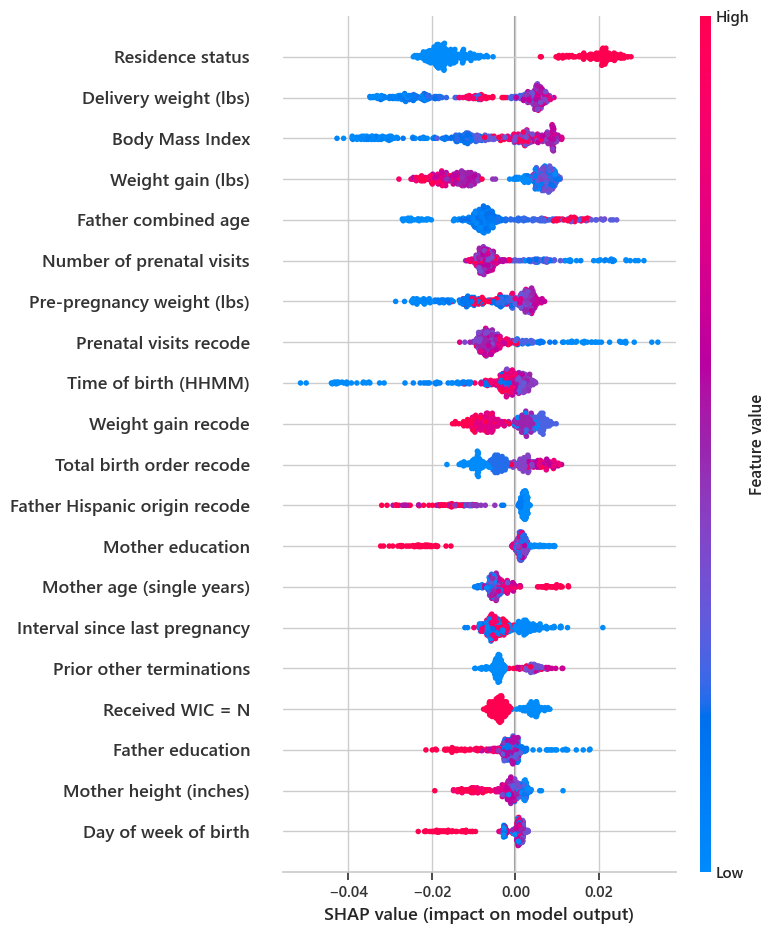

Leakage-safe SHAP Bar Plot


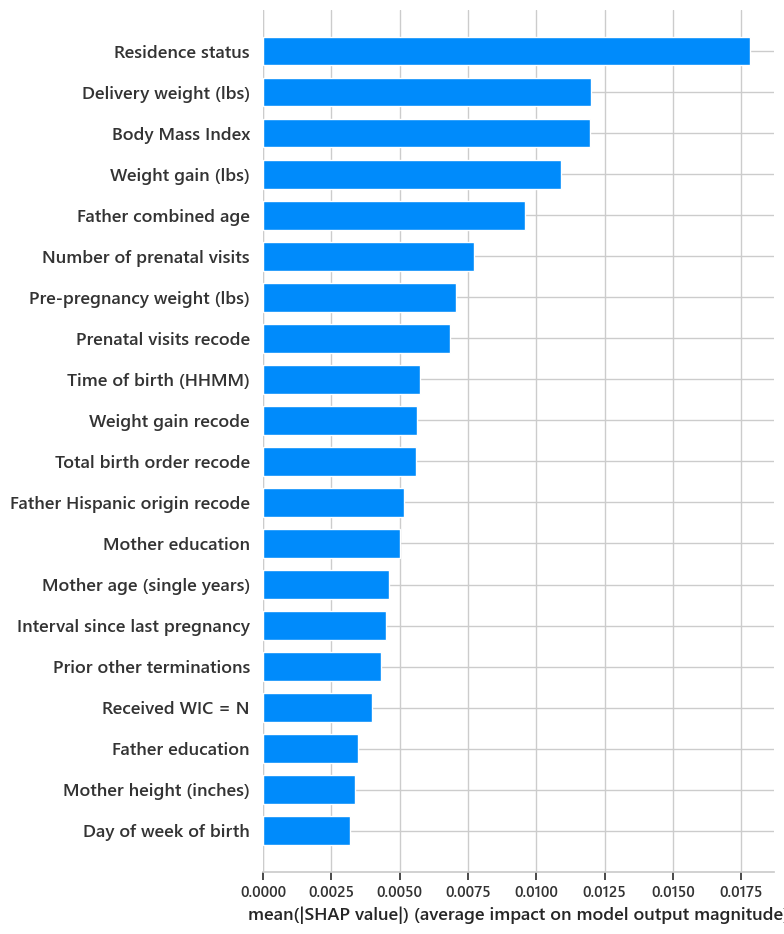

Leakage-safe SHAP Waterfall Plot
Selected case index: 34 | predicted risk=0.5672


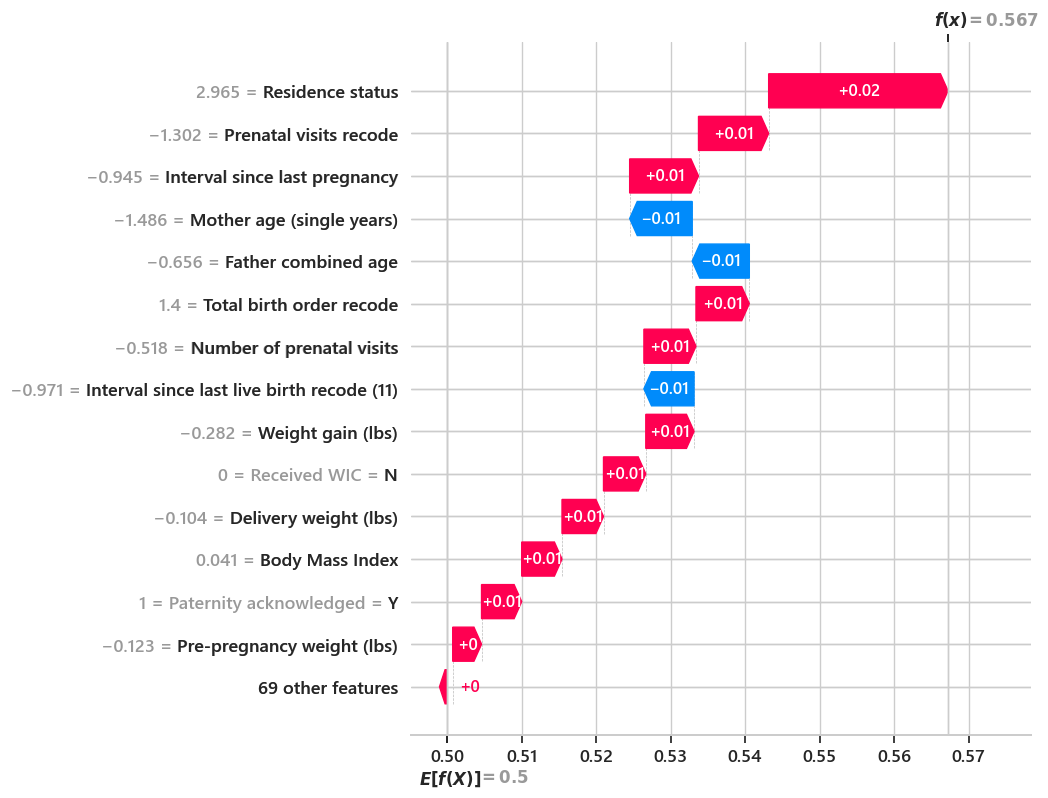

In [70]:
# 3.2 SHAP plots for leakage-safe model
from scipy import sparse

SAFE_SHAP_N = min(400, len(X_safe_test))
X_safe_shap_raw = X_safe_test.sample(SAFE_SHAP_N, random_state=42).copy()

safe_pre = safe_best_rf.named_steps["preprocess"]
safe_model = safe_best_rf.named_steps["model"]
X_safe_shap_trans = safe_pre.transform(X_safe_shap_raw)
safe_feature_names = safe_pre.get_feature_names_out()

def pretty_transformed_name(tname, categorical_source_cols):
    if "__" in tname:
        prefix, rest = tname.split("__", 1)
    else:
        prefix, rest = "", tname

    if prefix == "num":
        return friendly_name(rest) if "friendly_name" in globals() else rest

    if prefix == "cat":
        matches = [c for c in categorical_source_cols if rest == c or rest.startswith(c + "_")]
        if matches:
            base_col = max(matches, key=len)
            base_label = friendly_name(base_col) if "friendly_name" in globals() else base_col
            if rest == base_col:
                return base_label
            level = rest[len(base_col) + 1 :]
            return f"{base_label} = {level}"
        return rest

    return friendly_name(rest) if "friendly_name" in globals() else rest

safe_feature_display_names = [
    pretty_transformed_name(n, safe_categorical_cols if "safe_categorical_cols" in globals() else [])
    for n in safe_feature_names
]

safe_explainer = shap.TreeExplainer(safe_model)
safe_shap_raw = safe_explainer.shap_values(X_safe_shap_trans)

if isinstance(safe_shap_raw, list):
    safe_shap_values = safe_shap_raw[1] if len(safe_shap_raw) > 1 else safe_shap_raw[0]
elif isinstance(safe_shap_raw, np.ndarray) and safe_shap_raw.ndim == 3:
    safe_shap_values = safe_shap_raw[:, :, 1]
else:
    safe_shap_values = safe_shap_raw

safe_expected = safe_explainer.expected_value
if isinstance(safe_expected, (list, np.ndarray)):
    safe_expected = float(np.ravel(safe_expected)[-1])
else:
    safe_expected = float(safe_expected)

safe_mean_abs = np.abs(safe_shap_values).mean(axis=0)
safe_top_n = min(20, len(safe_mean_abs))
safe_top_idx = np.argsort(safe_mean_abs)[-safe_top_n:][::-1]
safe_top_names = np.array(safe_feature_names)[safe_top_idx]
safe_top_display_names = [pretty_transformed_name(n, safe_categorical_cols if "safe_categorical_cols" in globals() else []) for n in safe_top_names]

X_safe_top = X_safe_shap_trans[:, safe_top_idx]
if sparse.issparse(X_safe_top):
    X_safe_top = X_safe_top.toarray()

print("Leakage-safe SHAP Summary Plot (Beeswarm)")
shap.summary_plot(
    safe_shap_values[:, safe_top_idx],
    features=X_safe_top,
    feature_names=safe_top_display_names,
    max_display=min(20, len(safe_top_idx)),
    show=True
 )

print("Leakage-safe SHAP Bar Plot")
shap.summary_plot(
    safe_shap_values[:, safe_top_idx],
    features=X_safe_top,
    feature_names=safe_top_display_names,
    plot_type="bar",
    max_display=min(20, len(safe_top_idx)),
    show=True
 )

safe_pred_prob = safe_best_rf.predict_proba(X_safe_shap_raw)[:, 1]
safe_waterfall_idx = int(np.argmax(safe_pred_prob))
safe_row_trans = X_safe_shap_trans[safe_waterfall_idx]
if sparse.issparse(safe_row_trans):
    safe_row_trans = safe_row_trans.toarray().ravel()
else:
    safe_row_trans = np.asarray(safe_row_trans).ravel()

safe_waterfall = shap.Explanation(
    values=safe_shap_values[safe_waterfall_idx],
    base_values=safe_expected,
    data=safe_row_trans,
    feature_names=safe_feature_display_names
 )

print("Leakage-safe SHAP Waterfall Plot")
print(f"Selected case index: {safe_waterfall_idx} | predicted risk={safe_pred_prob[safe_waterfall_idx]:.4f}")
shap.plots.waterfall(safe_waterfall, max_display=15)

In [71]:
# 3.2 Leakage-safe interpretation
safe_interp_rows = []
safe_top_k = min(10, len(safe_top_idx))

for j in range(safe_top_k):
    idx = int(safe_top_idx[j])
    fname = safe_feature_names[idx]
    s_col = safe_shap_values[:, idx]

    f_col = X_safe_shap_trans[:, idx]
    if sparse.issparse(f_col):
        f_col = f_col.toarray().ravel()
    else:
        f_col = np.asarray(f_col).ravel()

    if np.nanstd(f_col) > 0 and np.nanstd(s_col) > 0:
        corr = np.corrcoef(f_col, s_col)[0, 1]
    else:
        corr = np.nan

    if np.isnan(corr):
        direction = "mixed/flat"
    elif corr > 0.05:
        direction = "higher values increase risk"
    elif corr < -0.05:
        direction = "higher values decrease risk"
    else:
        direction = "weak/mixed direction"

    safe_interp_rows.append({
        "feature": fname,
        "mean_abs_shap": float(np.mean(np.abs(s_col))),
        "mean_shap": float(np.mean(s_col)),
        "value_shap_corr": float(corr) if not np.isnan(corr) else np.nan,
        "direction": direction
    })

safe_shap_interpretation_df = pd.DataFrame(safe_interp_rows).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
display(safe_shap_interpretation_df)

print("Leakage-safe interpretation:")
print("- Strongest impact pre-birth features are ranked above by mean |SHAP|.")
print("- Positive SHAP values increase predicted cleft risk; negative SHAP values reduce predicted risk.")
print("- This version is better for decision support because it excludes post-birth leakage variables.")

,feature,mean_abs_shap,mean_shap,value_shap_corr,direction
0,num__RESTATUS,0.017806,-0.004510,0.912635,higher values increase risk
1,num__DWgt_R,0.012001,-0.006693,0.427672,higher values increase risk
2,num__BMI,0.011945,-0.007015,0.399729,higher values increase risk
3,num__WTGAIN,0.010897,-0.004515,-0.740622,higher values decrease risk
4,num__FAGECOMB,0.009576,-0.004356,0.720565,higher values increase risk
5,num__PREVIS,0.007702,-0.003534,-0.256874,higher values decrease risk
6,num__PWgt_R,0.007041,-0.004221,0.135300,higher values increase risk
7,num__PREVIS_REC,0.006840,-0.003305,-0.624463,higher values decrease risk
8,num__DOB_TT,0.005751,-0.004417,0.414999,higher values increase risk
9,num__WTGAIN_REC,0.005646,-0.001485,-0.770807,higher values decrease risk


Leakage-safe interpretation:
- Strongest impact pre-birth features are ranked above by mean |SHAP|.
- Positive SHAP values increase predicted cleft risk; negative SHAP values reduce predicted risk.
- This version is better for decision support because it excludes post-birth leakage variables.


## Part 4: Streamlit Deployment Artifacts
This section saves pre-trained models and all analysis artifacts needed by the Streamlit app.

In [72]:
# Export pre-trained models and analytics artifacts for Streamlit
from pathlib import Path
import json
import joblib

artifacts_dir = Path.cwd() / "streamlit_artifacts"
models_dir = artifacts_dir / "models"
artifacts_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

def _to_py(v):
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, (np.floating,)):
        return float(v)
    if isinstance(v, (np.bool_,)):
        return bool(v)
    return v

# 1) Save model comparison + hyperparameters
if "results_df" in globals():
    results_df.to_csv(artifacts_dir / "results_df.csv", index=False)

if "best_params_log" in globals():
    best_params_clean = {k: {kk: _to_py(vv) for kk, vv in v.items()} if isinstance(v, dict) else str(v) for k, v in best_params_log.items()}
    with open(artifacts_dir / "best_params_log.json", "w", encoding="utf-8") as f:
        json.dump(best_params_clean, f, indent=2)

# 2) Save pre-trained sklearn models
saved_models = {}
if "logit_pipe" in globals():
    joblib.dump(logit_pipe, models_dir / "logistic_regression.joblib")
    saved_models["Logistic Regression"] = {"type": "sklearn", "path": "models/logistic_regression.joblib", "feature_space": "full"}
if "best_dt" in globals():
    joblib.dump(best_dt, models_dir / "decision_tree.joblib")
    saved_models["Decision Tree"] = {"type": "sklearn", "path": "models/decision_tree.joblib", "feature_space": "full"}
if "best_rf" in globals():
    joblib.dump(best_rf, models_dir / "random_forest.joblib")
    saved_models["Random Forest"] = {"type": "sklearn", "path": "models/random_forest.joblib", "feature_space": "full"}
if "best_xgb" in globals():
    joblib.dump(best_xgb, models_dir / "xgboost.joblib")
    saved_models["XGBoost"] = {"type": "sklearn", "path": "models/xgboost.joblib", "feature_space": "full"}
if "safe_best_rf" in globals():
    joblib.dump(safe_best_rf, models_dir / "leakage_safe_random_forest.joblib")
    saved_models["Leakage-safe Random Forest"] = {"type": "sklearn", "path": "models/leakage_safe_random_forest.joblib", "feature_space": "safe"}

# 3) Save Keras model + preprocessor if available
if "mlp" in globals() and "nn_preprocessor" in globals():
    mlp_save_path = models_dir / "mlp.keras"
    mlp.save(mlp_save_path)
    joblib.dump(nn_preprocessor, models_dir / "mlp_preprocessor.joblib")
    saved_models["MLP (Keras)"] = {
        "type": "keras",
        "path": "models/mlp.keras",
        "preprocessor_path": "models/mlp_preprocessor.joblib",
        "feature_space": "full"
    }

with open(artifacts_dir / "model_registry.json", "w", encoding="utf-8") as f:
    json.dump(saved_models, f, indent=2)

# 4) Save test datasets for evaluation plots in app
if "X_test" in globals() and "y_test" in globals():
    X_test.to_pickle(artifacts_dir / "X_test_full.pkl")
    y_test.to_pickle(artifacts_dir / "y_test_full.pkl")

if "X_safe_test" in globals() and "y_safe_test" in globals():
    X_safe_test.to_pickle(artifacts_dir / "X_test_safe.pkl")
    y_safe_test.to_pickle(artifacts_dir / "y_test_safe.pkl")

# 5) Save descriptive analytics snapshot
eda_cols_streamlit = [c for c in [
    "cleft_case", "MAGER14", "CIG_REC", "MEDUC", "SEX", "WIC",
    "COMBGEST", "OEGest_Comb", "MAGER", "FAGECOMB", "PREVIS",
    "WTGAIN", "M_Ht_In", "BMI", "PRECARE", "PRECARE5"
] if c in nat2024us.columns]
eda_snapshot = nat2024us[eda_cols_streamlit].sample(min(50000, len(nat2024us)), random_state=42).copy()
eda_snapshot.to_pickle(artifacts_dir / "eda_snapshot.pkl")

# 6) Save interactive schemas and baseline rows
full_baseline = {}
full_schema = {}
if "X_train" in globals():
    for col in X_train.columns:
        s = X_train[col]
        if pd.api.types.is_numeric_dtype(s):
            full_baseline[col] = float(pd.to_numeric(s, errors="coerce").median())
            full_schema[col] = {
                "type": "numeric",
                "min": float(pd.to_numeric(s, errors="coerce").quantile(0.01)),
                "max": float(pd.to_numeric(s, errors="coerce").quantile(0.99)),
                "default": full_baseline[col]
            }
        else:
            s_obj = s.astype("object").where(s.notna(), np.nan)
            mode_vals = s_obj.mode(dropna=True)
            baseline = str(mode_vals.iloc[0]) if len(mode_vals) > 0 else "Unknown"
            cats = [str(x) for x in s_obj.dropna().astype(str).value_counts().head(20).index.tolist()]
            full_baseline[col] = baseline
            full_schema[col] = {"type": "categorical", "options": cats, "default": baseline}

safe_baseline = {}
safe_schema = {}
if "X_safe_train" in globals():
    for col in X_safe_train.columns:
        s = X_safe_train[col]
        if pd.api.types.is_numeric_dtype(s):
            safe_baseline[col] = float(pd.to_numeric(s, errors="coerce").median())
            safe_schema[col] = {
                "type": "numeric",
                "min": float(pd.to_numeric(s, errors="coerce").quantile(0.01)),
                "max": float(pd.to_numeric(s, errors="coerce").quantile(0.99)),
                "default": safe_baseline[col]
            }
        else:
            s_obj = s.astype("object").where(s.notna(), np.nan)
            mode_vals = s_obj.mode(dropna=True)
            baseline = str(mode_vals.iloc[0]) if len(mode_vals) > 0 else "Unknown"
            cats = [str(x) for x in s_obj.dropna().astype(str).value_counts().head(20).index.tolist()]
            safe_baseline[col] = baseline
            safe_schema[col] = {"type": "categorical", "options": cats, "default": baseline}

interactive_feature_candidates = [
    "RESTATUS", "DWgt_R", "BMI", "WTGAIN", "FAGECOMB", "PREVIS", "PWgt_R", "MAGER", "WIC"
]

payload = {
    "interactive_features": interactive_feature_candidates,
    "full_baseline": full_baseline,
    "full_schema": full_schema,
    "safe_baseline": safe_baseline,
    "safe_schema": safe_schema,
    "notes": "Models are pre-trained in notebook; Streamlit must only load and infer."
}

with open(artifacts_dir / "interactive_schema.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print(f"Artifacts exported to: {artifacts_dir}")
print("Saved files:")
for p in sorted(artifacts_dir.rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(artifacts_dir))

Artifacts exported to: c:\Users\mimarqu\OneDrive - Microsoft\UW\Winter 2026\Leo\522\Homework 1\streamlit_artifacts
Saved files:
 - best_params_log.json
 - data_dictionary.csv
 - data_dictionary.pkl
 - eda_snapshot.pkl
 - interactive_schema.json
 - model_registry.json
 - models\decision_tree.joblib
 - models\leakage_safe_random_forest.joblib
 - models\logistic_regression.joblib
 - models\mlp.keras
 - models\mlp_preprocessor.joblib
 - models\random_forest.joblib
 - models\xgboost.joblib
 - results_df.csv
 - sex_wic_heatmap_full.csv
 - X_test_full.pkl
 - X_test_safe.pkl
 - y_test_full.pkl
 - y_test_safe.pkl


In [73]:
# Export full data dictionary for Streamlit Tab 1 (no truncation)
from pathlib import Path

artifacts_dir = Path.cwd() / "streamlit_artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

if "data_dictionary" not in globals() or data_dictionary is None:
    raise RuntimeError("`data_dictionary` not found. Run the data dictionary cells first.")

# Preserve full table exactly as created in notebook.
data_dictionary.to_pickle(artifacts_dir / "data_dictionary.pkl")
data_dictionary.to_csv(artifacts_dir / "data_dictionary.csv", index=False)

print(f"Saved full data dictionary with {len(data_dictionary):,} rows")
print(" - streamlit_artifacts/data_dictionary.pkl")
print(" - streamlit_artifacts/data_dictionary.csv")

Saved full data dictionary with 89 rows
 - streamlit_artifacts/data_dictionary.pkl
 - streamlit_artifacts/data_dictionary.csv


In [74]:
# Export full SEX x WIC heatmap data for Streamlit Tab 2 parity with notebook
from pathlib import Path

artifacts_dir = Path.cwd() / "streamlit_artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

if "nat2024us" not in globals() or "cleft_case" not in nat2024us.columns:
    raise RuntimeError("nat2024us with cleft_case is required. Run Part 1 setup cells first.")

heat_df_full = (
    nat2024us.dropna(subset=["SEX", "WIC", "cleft_case"])
    .groupby(["SEX", "WIC"], as_index=False)
    .agg(cases=("cleft_case", "sum"), births=("cleft_case", "count"))
)
heat_df_full["prev_per_10k"] = heat_df_full["cases"] / heat_df_full["births"] * 10000

heat_df_full.to_csv(artifacts_dir / "sex_wic_heatmap_full.csv", index=False)

print(f"Saved full heatmap artifact with {len(heat_df_full):,} rows")
print(" - streamlit_artifacts/sex_wic_heatmap_full.csv")

Saved full heatmap artifact with 6 rows
 - streamlit_artifacts/sex_wic_heatmap_full.csv
